In [1]:
from icxcca import *
import pynapple as nap
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

import logging

logging.basicConfig(level=logging.INFO)

data_filenames = [
    "2022_04_12_0002.csv",
    "2022_04_12_0004.csv",
    "2022_04_13_0005.csv",
    "2022_04_14_0001.csv",
    "2022_04_14_0002.csv",
    "2022_04_14_0003.csv",
    "2022_04_28_0012.csv",
    "2022_04_28_0015.csv",
    "2022_04_28_0016.csv",
]

data_dir = "../data/processed"

data_filepaths = [Path(data_dir) / Path(f) for f in data_filenames]


INFO:icxcca.data:Initializing DataManager for ../data/processed/2022_04_12_0002.csv
INFO:icxcca.data:Loading data from ../data/processed/2022_04_12_0002.csv
INFO:icxcca.data:Detected CSV header row 0 for ../data/processed/2022_04_12_0002.csv
INFO:icxcca.data:Loaded 50 features from ../data/processed/2022_04_12_0002.csv
INFO:icxcca.data:Plot requested for ../data/processed/2022_04_12_0002.csv with features_per_subplot=2, autosave=True
INFO:icxcca.data:Plotting 50 features across 25 subplots
INFO:icxcca.data:Using shared y-limits: [-120.8496, 190.0]
INFO:icxcca.data:Created feature plot figure
INFO:icxcca.data:Derived figure filename 2022_04_12_0002.png from ../data/processed/2022_04_12_0002.csv
INFO:icxcca.data:Saving figure to 2022_04_12_0002.png


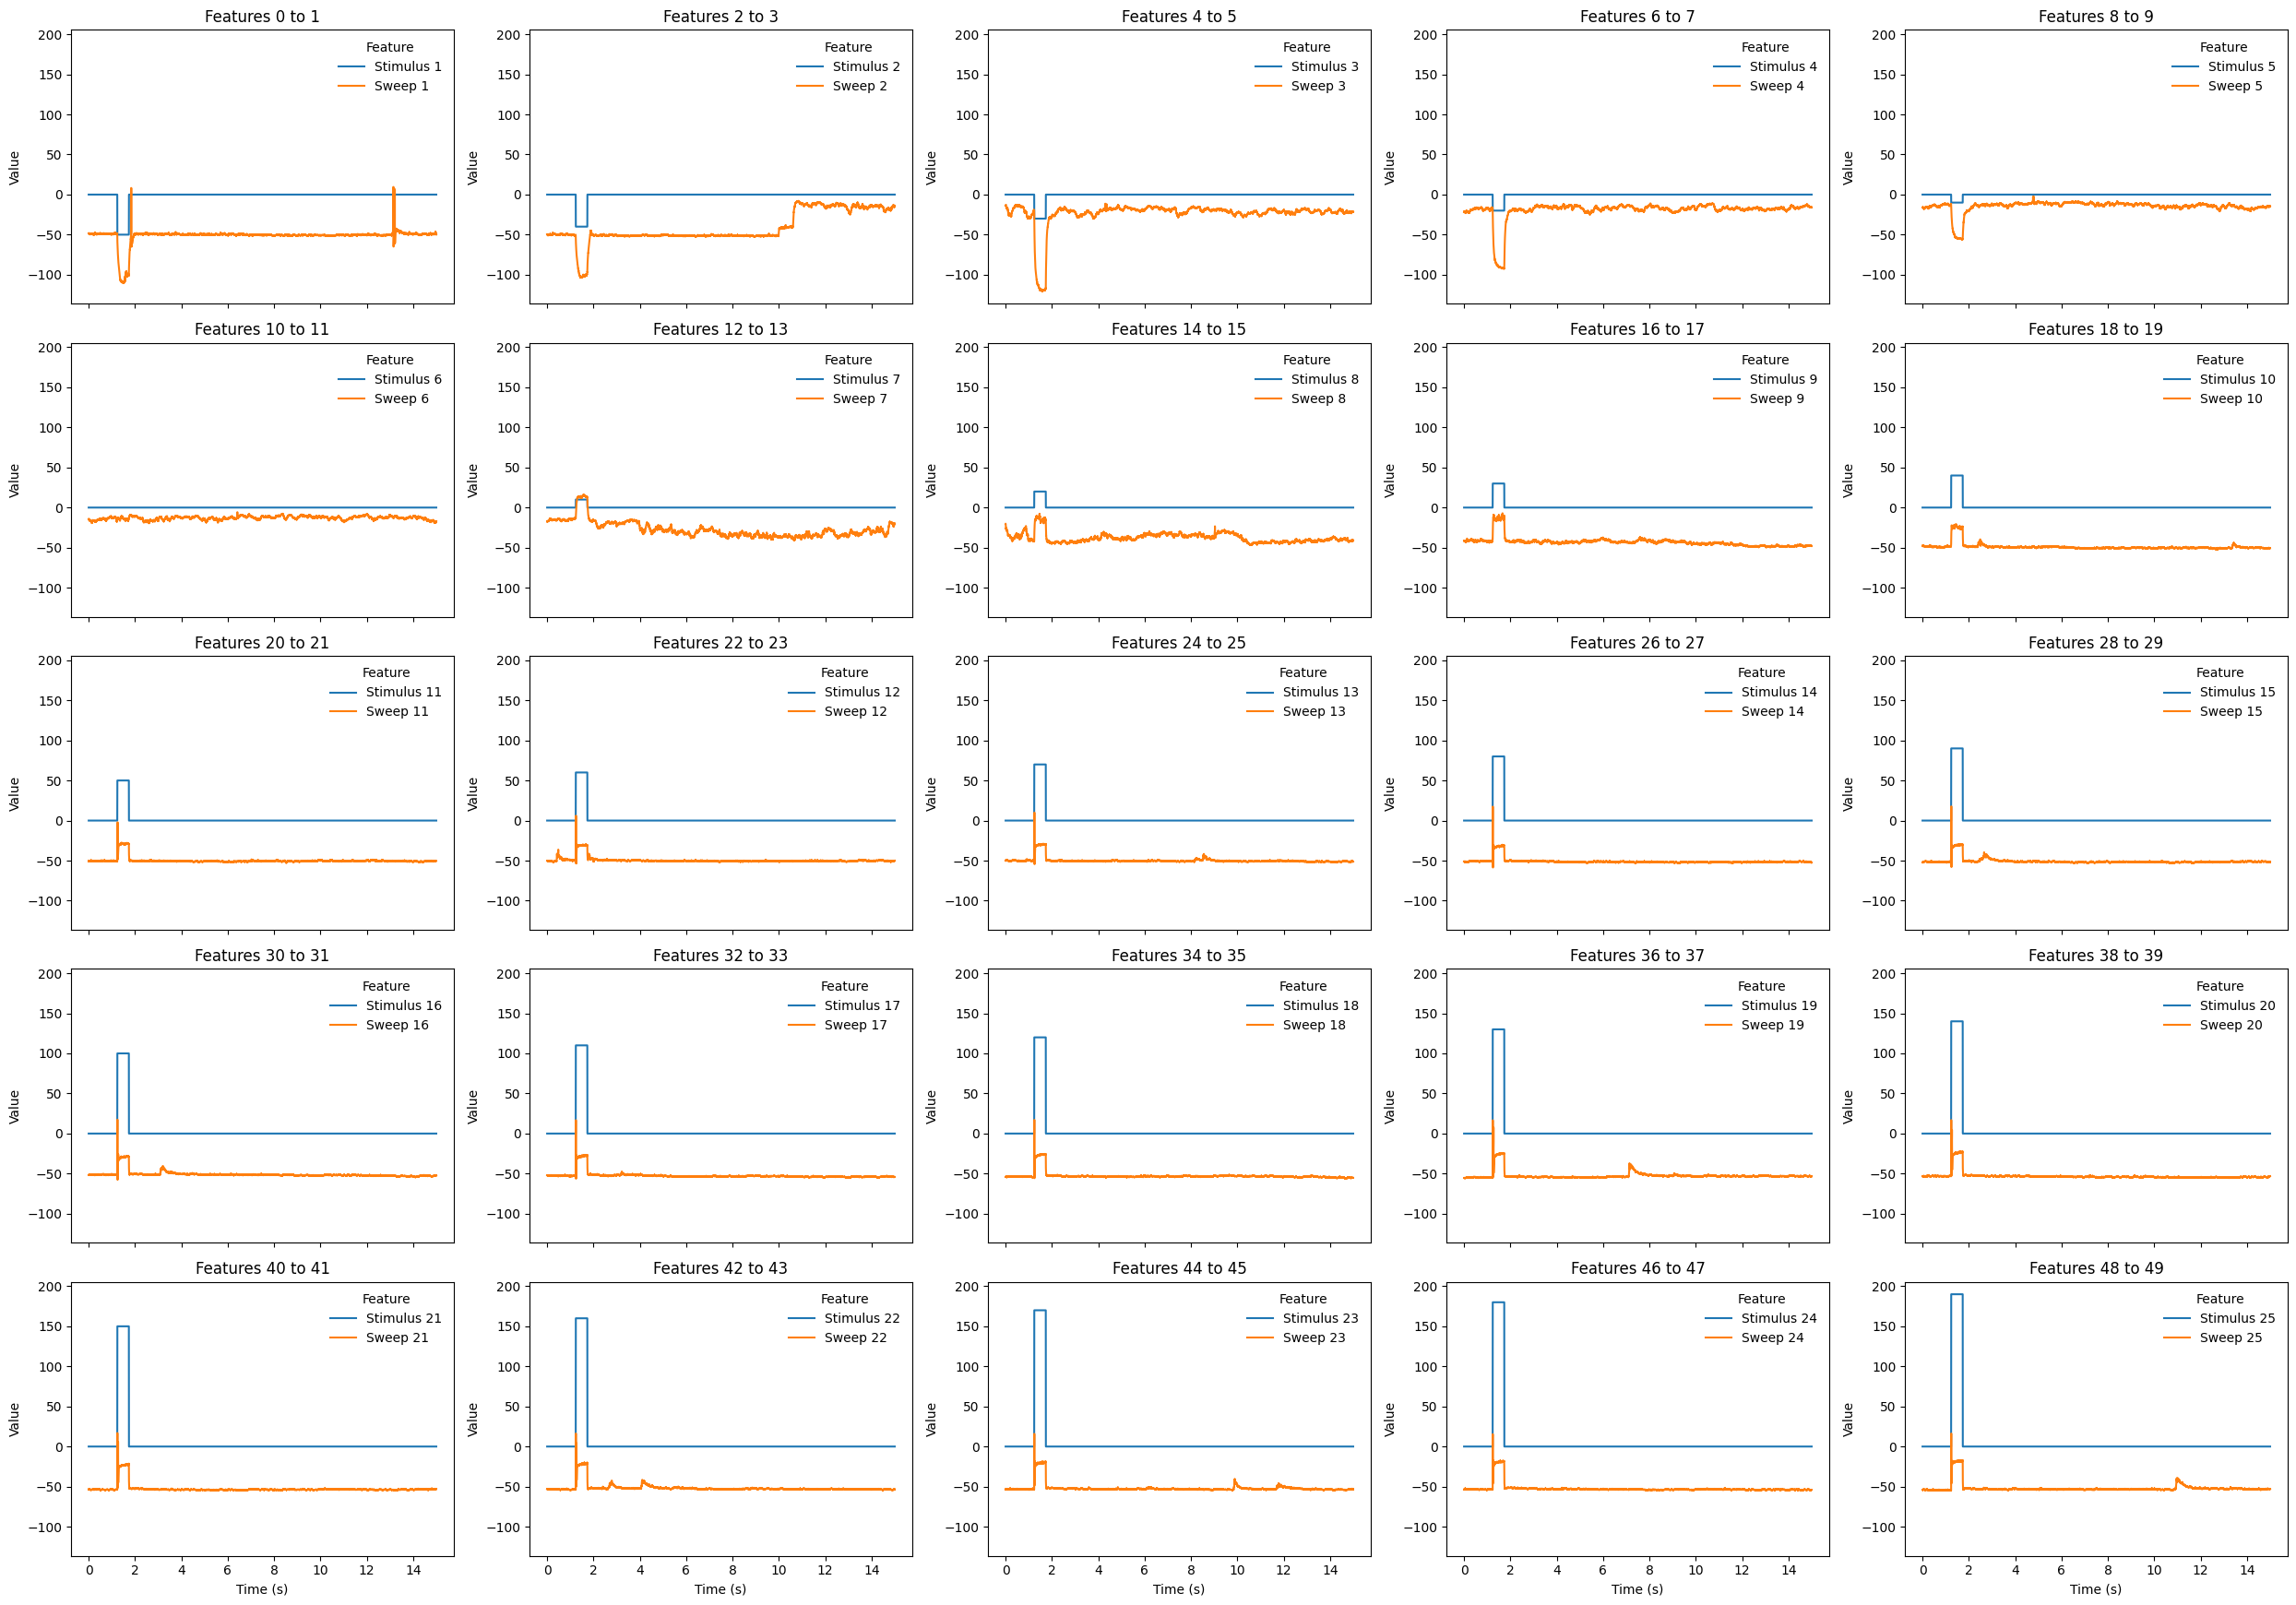

In [3]:
data_filename = "../data/processed/2022_04_12_0002.csv"
dm = DataManager(data_filename)
fig, _ = dm.plot(autosave=True)

In [4]:
# for fp in data_filepaths:
#     dm = DataManager(fp)
#     fig, _ = dm.plot()
#     name = Path(fp).stem
#     print(name)
#     fig.savefig(f"{name}_processed.png")


In [5]:
# look at the same interval for all files

# interval = nap.IntervalSet(start=1.0, end=2.0, time_units="s")
# for data_filename in files:
#     data = get_data(data_filename).restrict(interval)
#     plt.figure()
#     plt.plot(data.t, data.d, marker="")
#     plt.title(data_filename)
#     plt.xlabel("Time (s)")
#     plt.show()

INFO:icxcca.data:Initializing DataManager for ..\data\processed\2022_04_12_0002.csv
INFO:icxcca.data:Loading data from ..\data\processed\2022_04_12_0002.csv
INFO:icxcca.data:Detected CSV header row 0 for ..\data\processed\2022_04_12_0002.csv
INFO:icxcca.data:Loaded 50 features from ..\data\processed\2022_04_12_0002.csv
INFO:icxcca.data:Plot requested for ..\data\processed\2022_04_12_0002.csv with features_per_subplot=2, autosave=False
INFO:icxcca.data:Plotting 50 features across 25 subplots
INFO:icxcca.data:Using shared y-limits: [-120.8496, 190.0]
INFO:icxcca.data:Created feature plot figure
INFO:icxcca.data:Writing pynapple data to ..\data\npz\2022_04_12_0002_trunc.npz
INFO:icxcca.data:Wrote pynapple data to ..\data\npz\2022_04_12_0002_trunc.npz
INFO:icxcca.data:Initializing DataManager for ..\data\processed\2022_04_12_0004.csv
INFO:icxcca.data:Loading data from ..\data\processed\2022_04_12_0004.csv
INFO:icxcca.data:Detected CSV header row 0 for ..\data\processed\2022_04_12_0004.csv


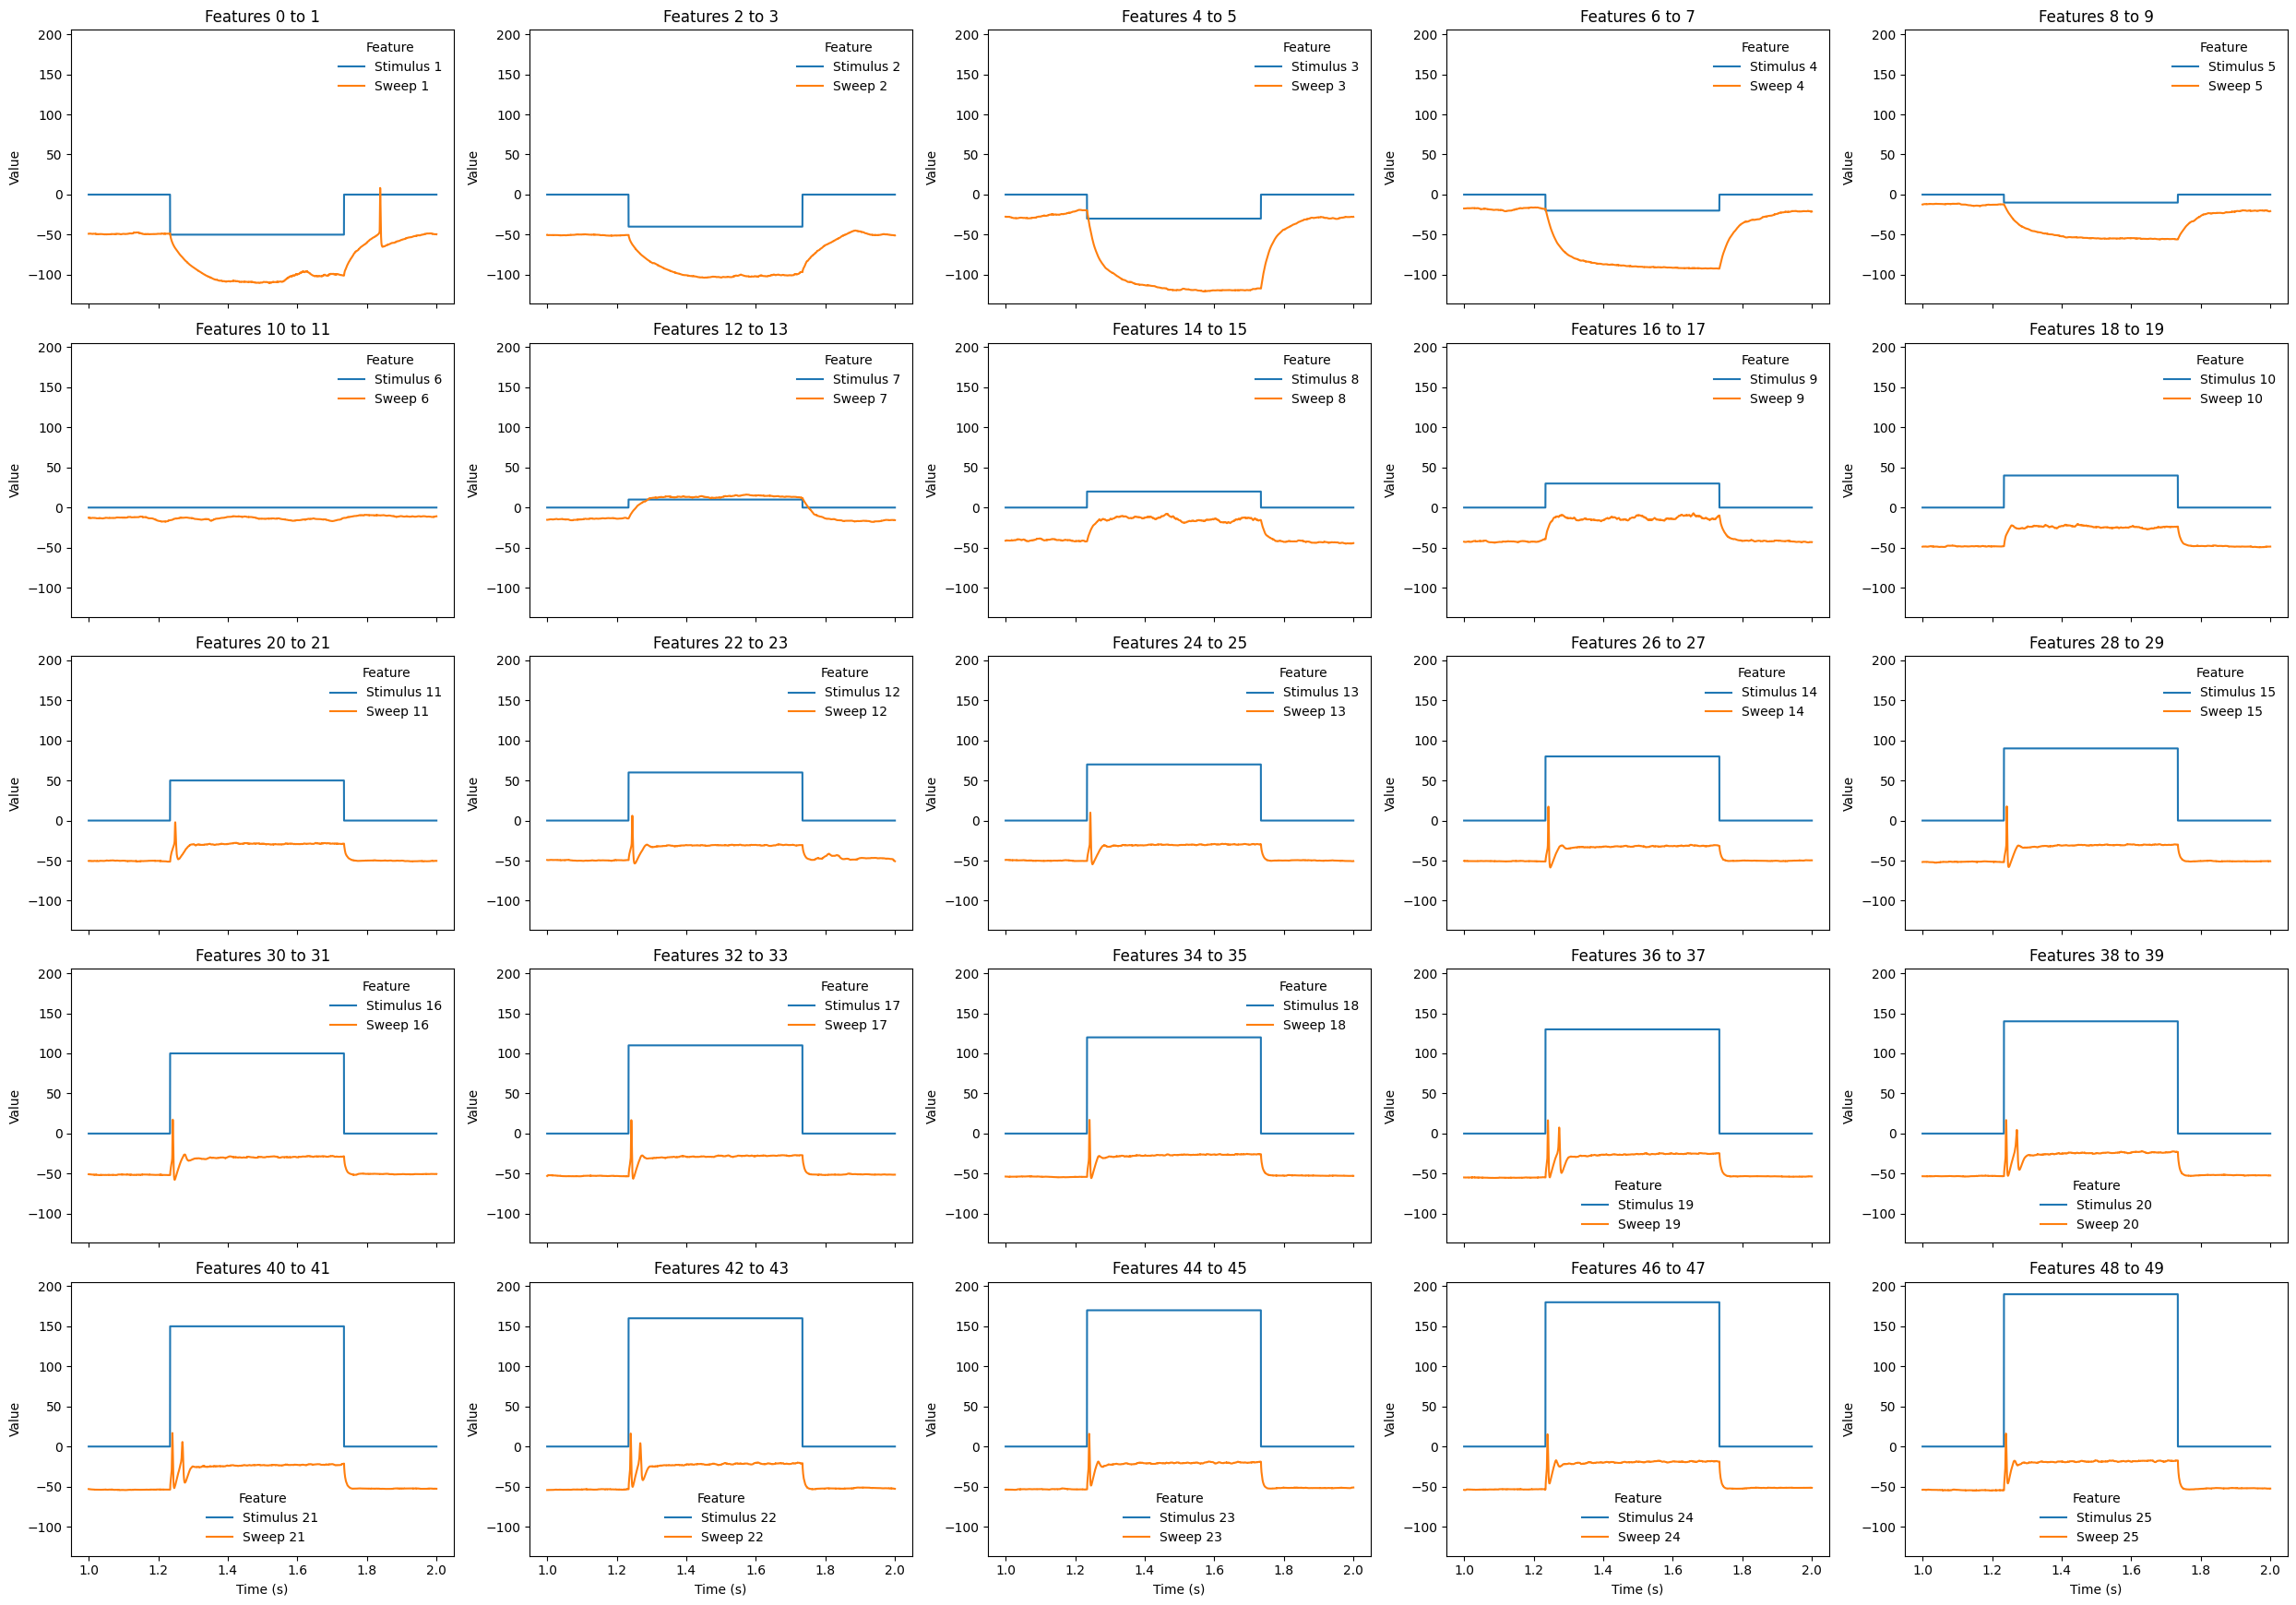

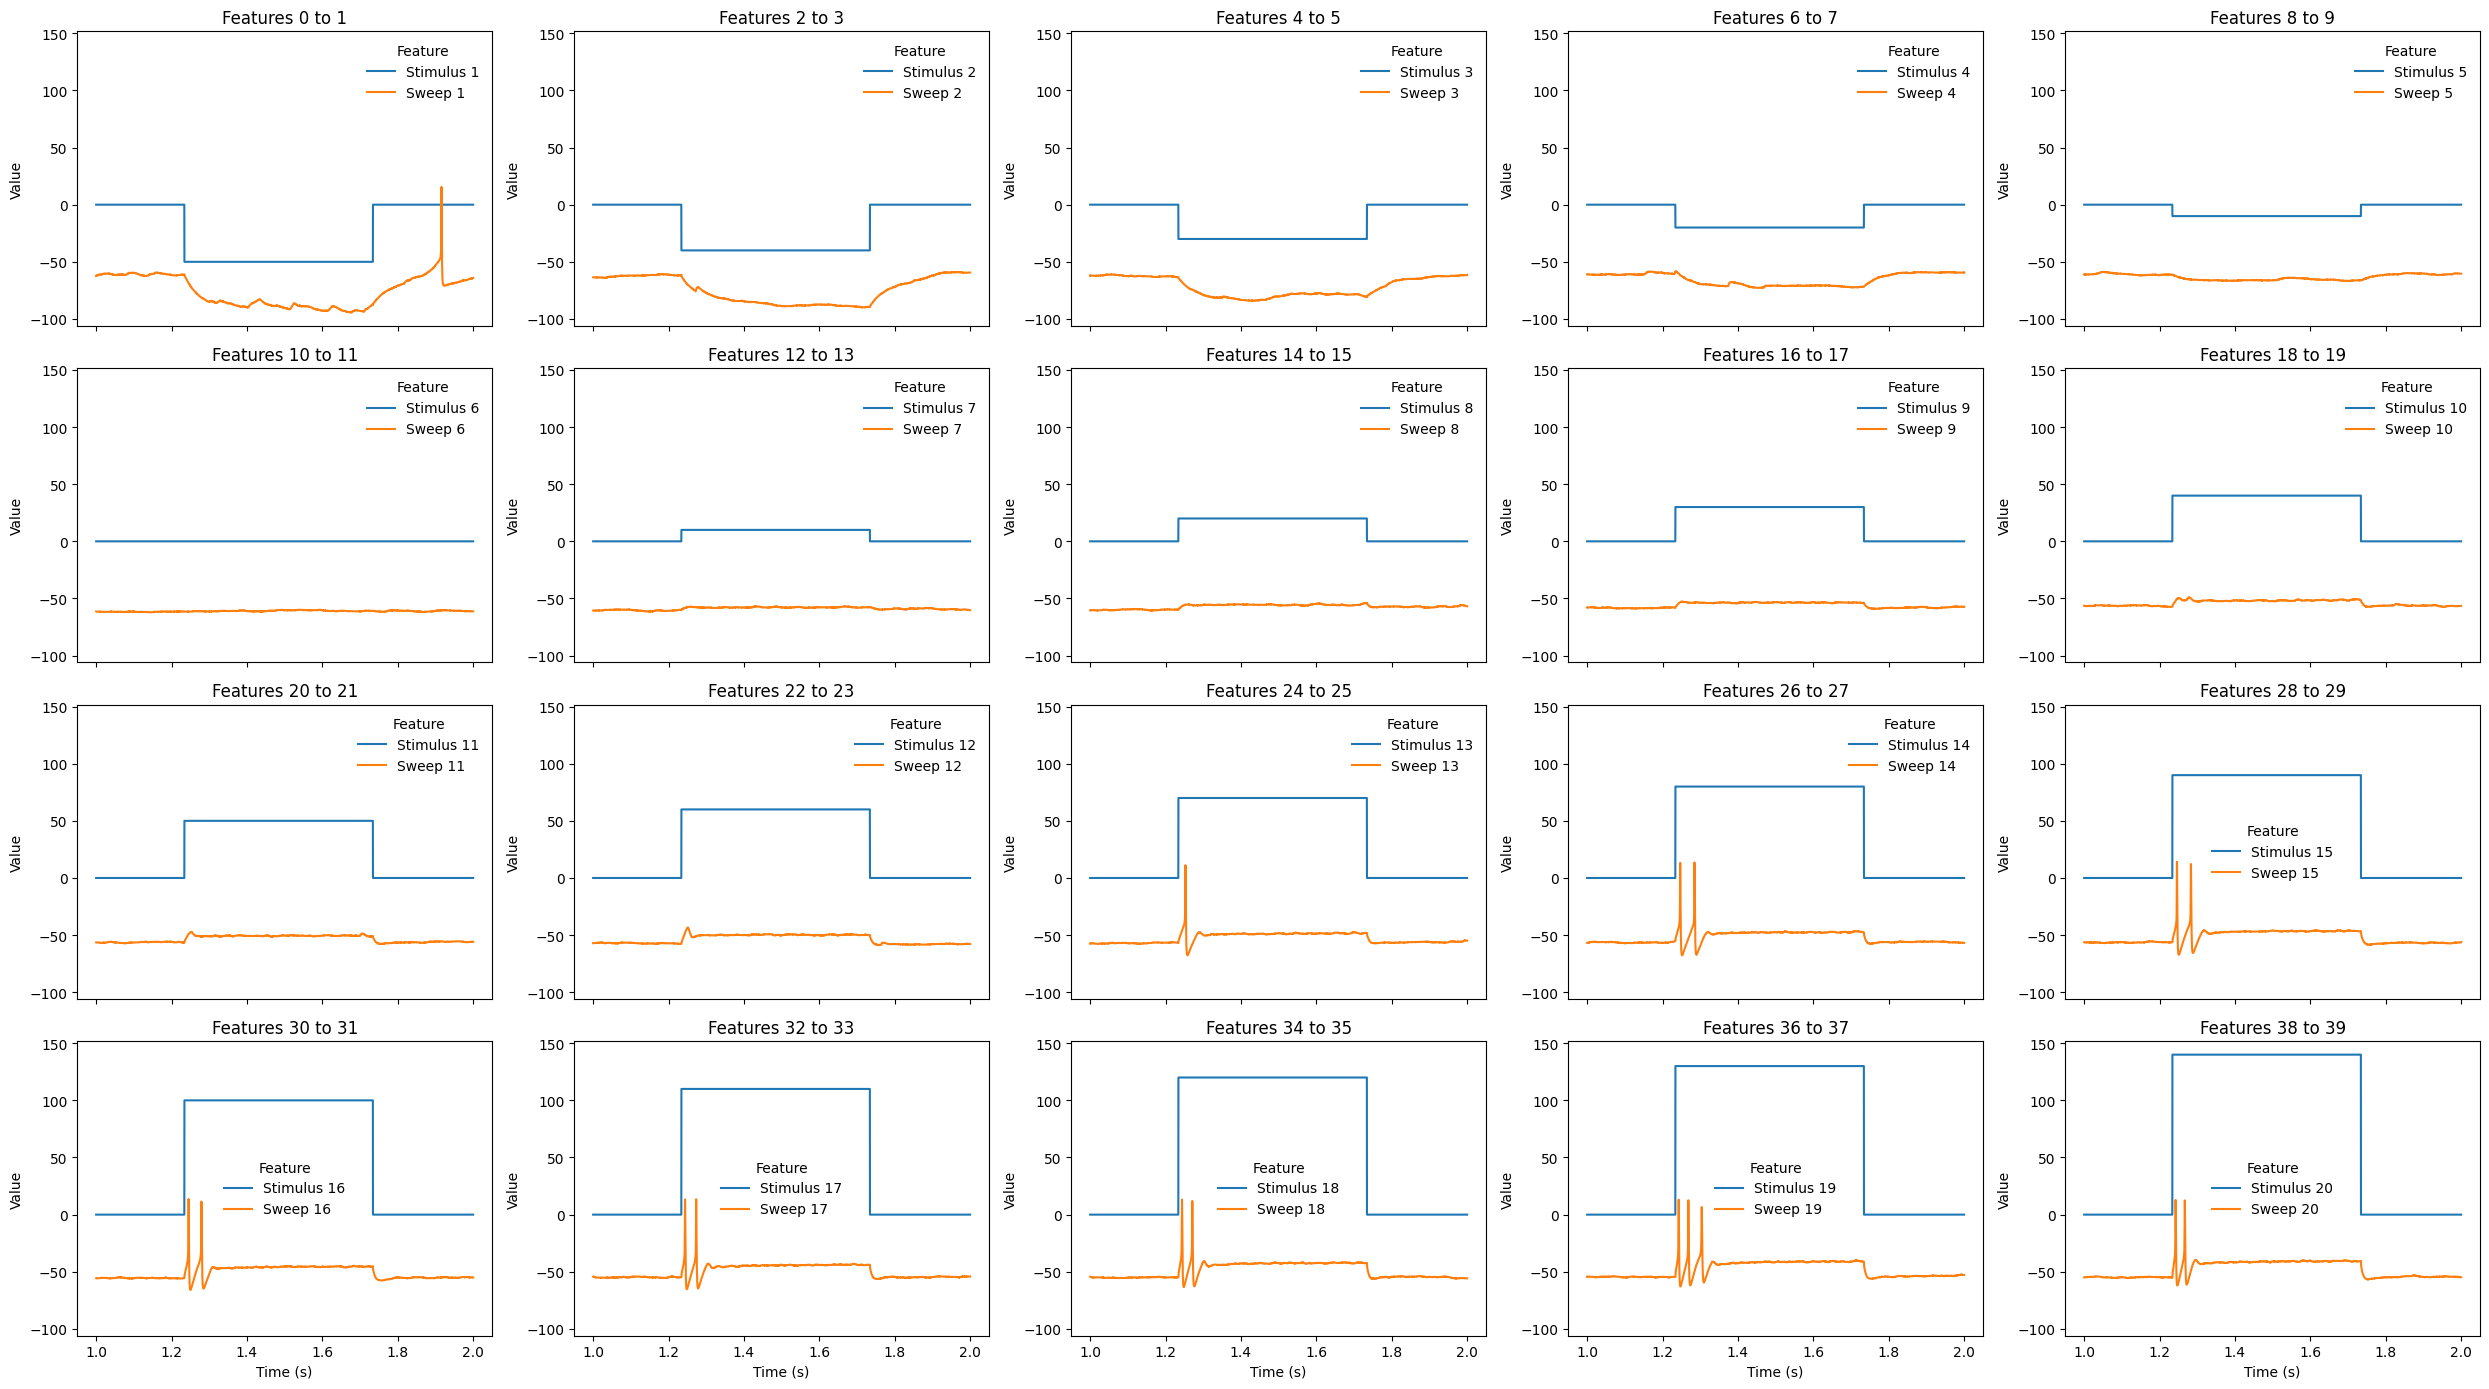

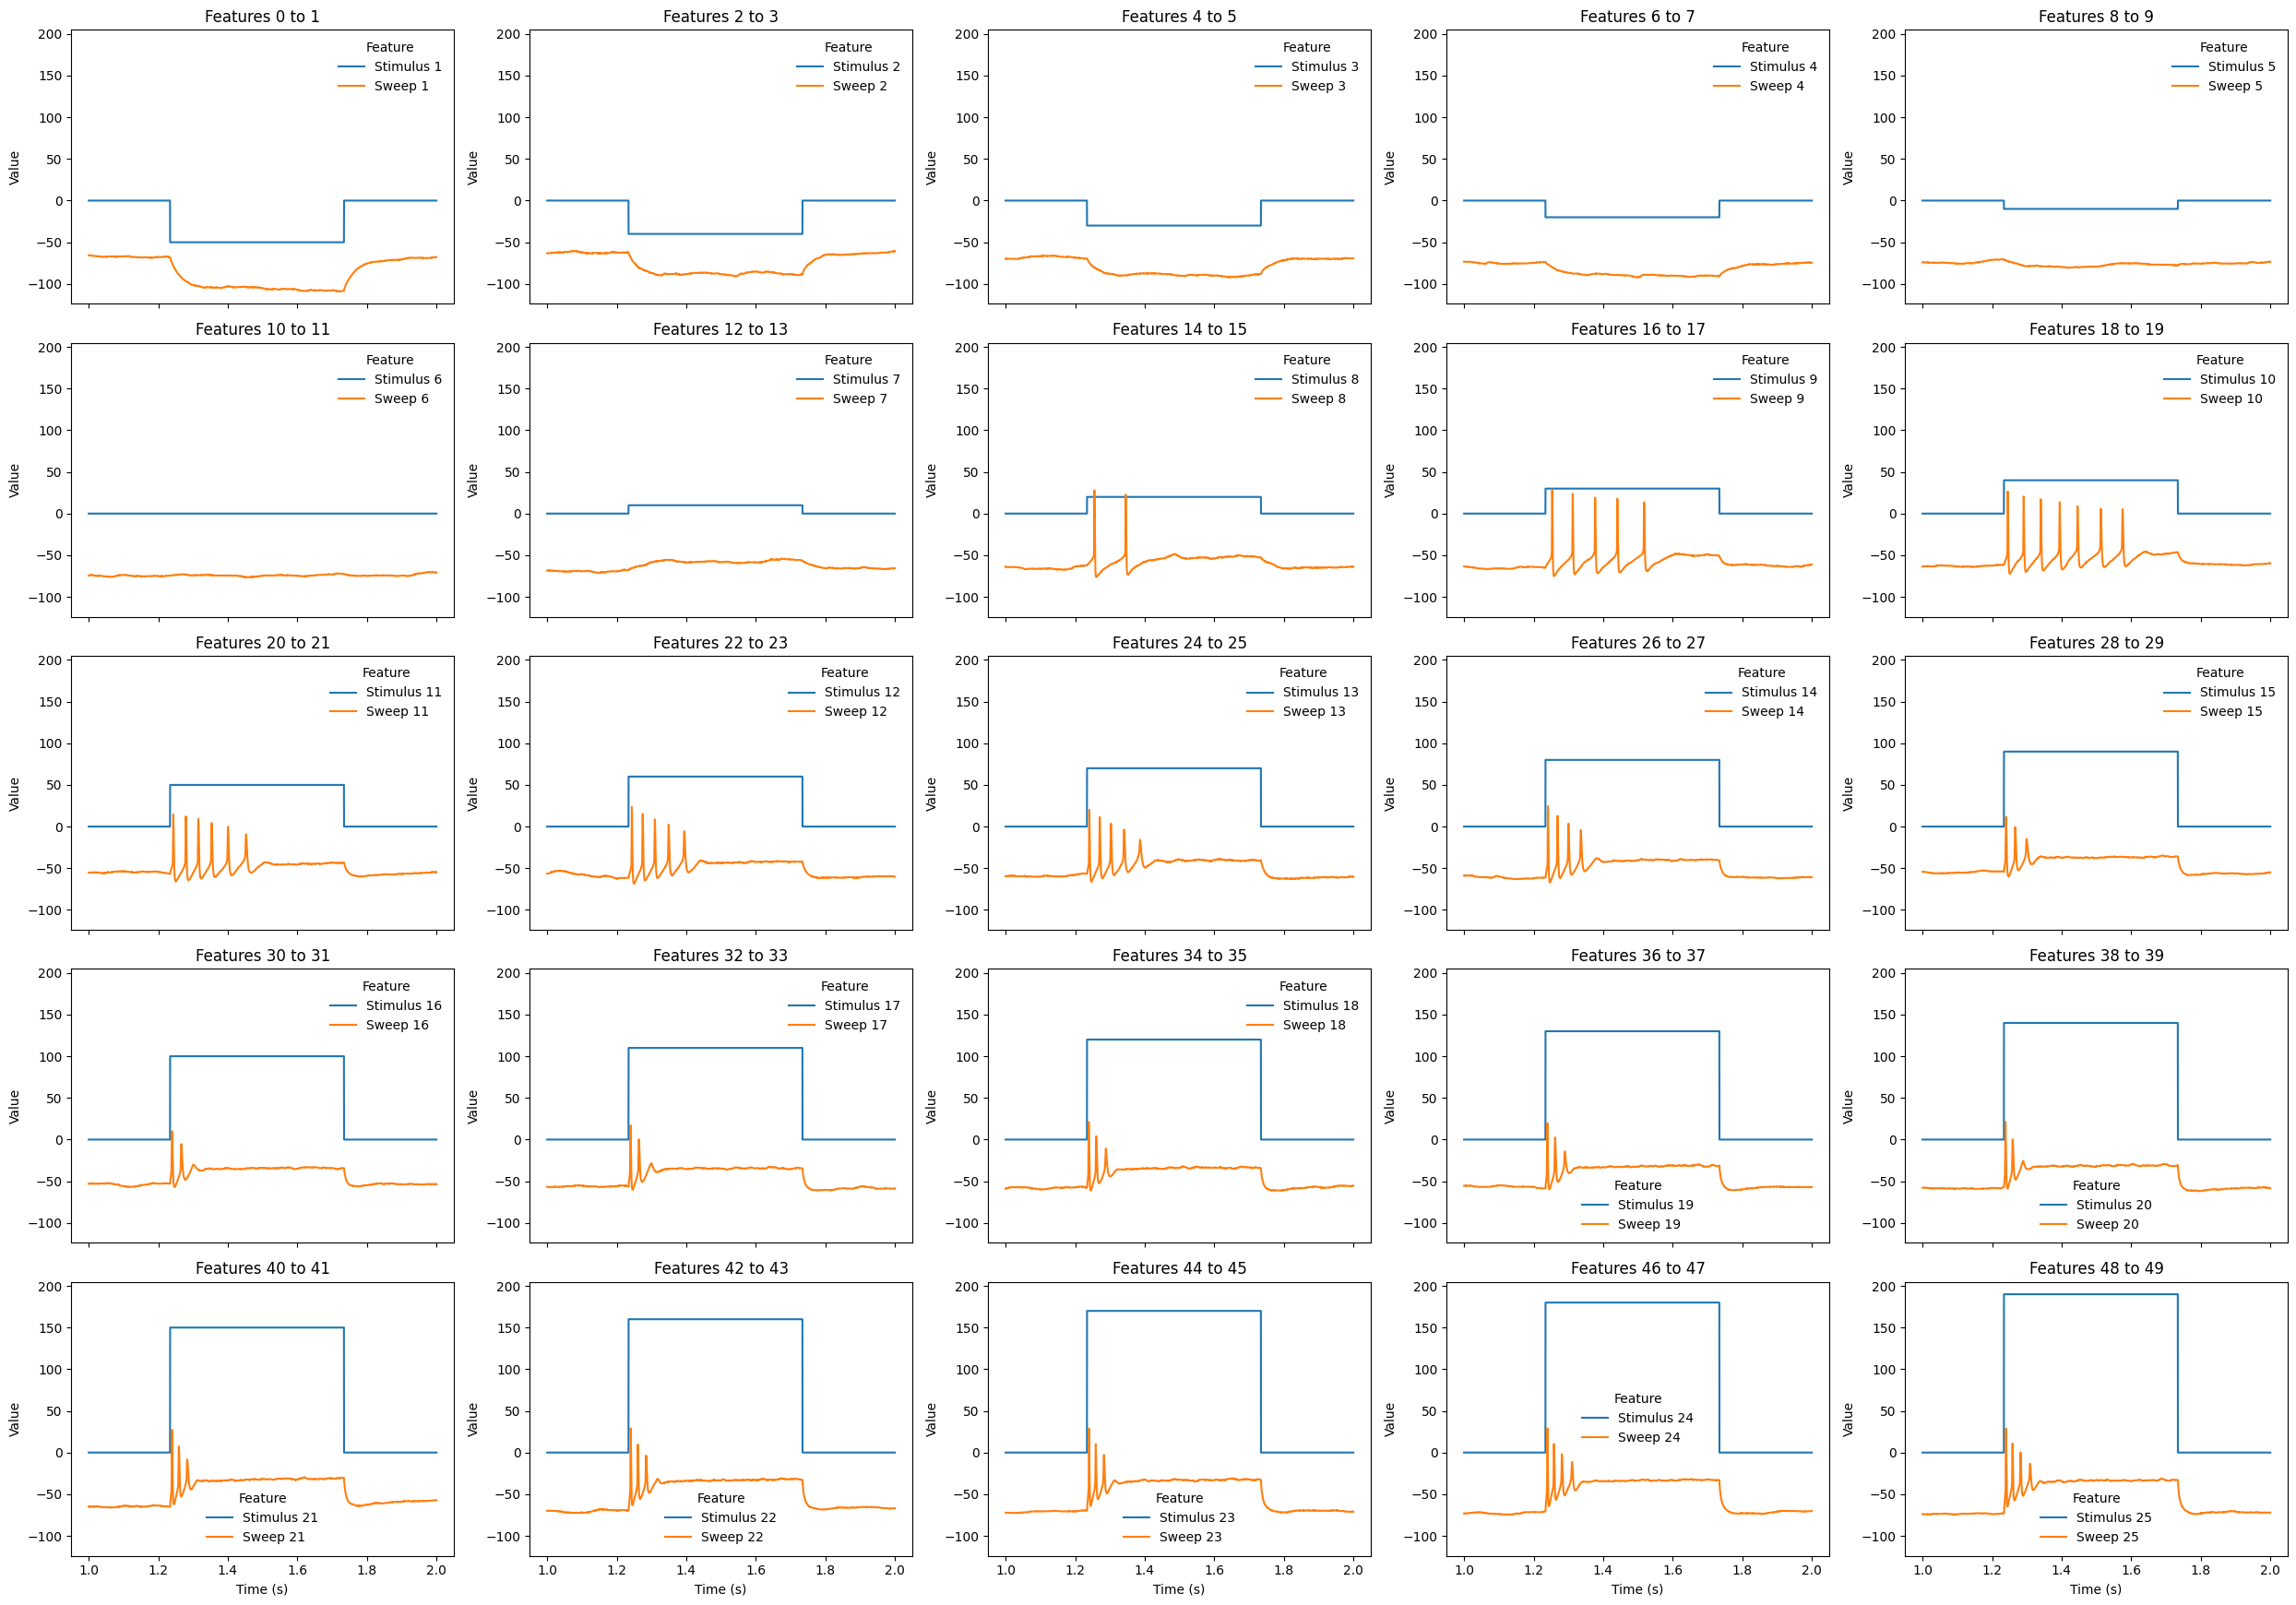

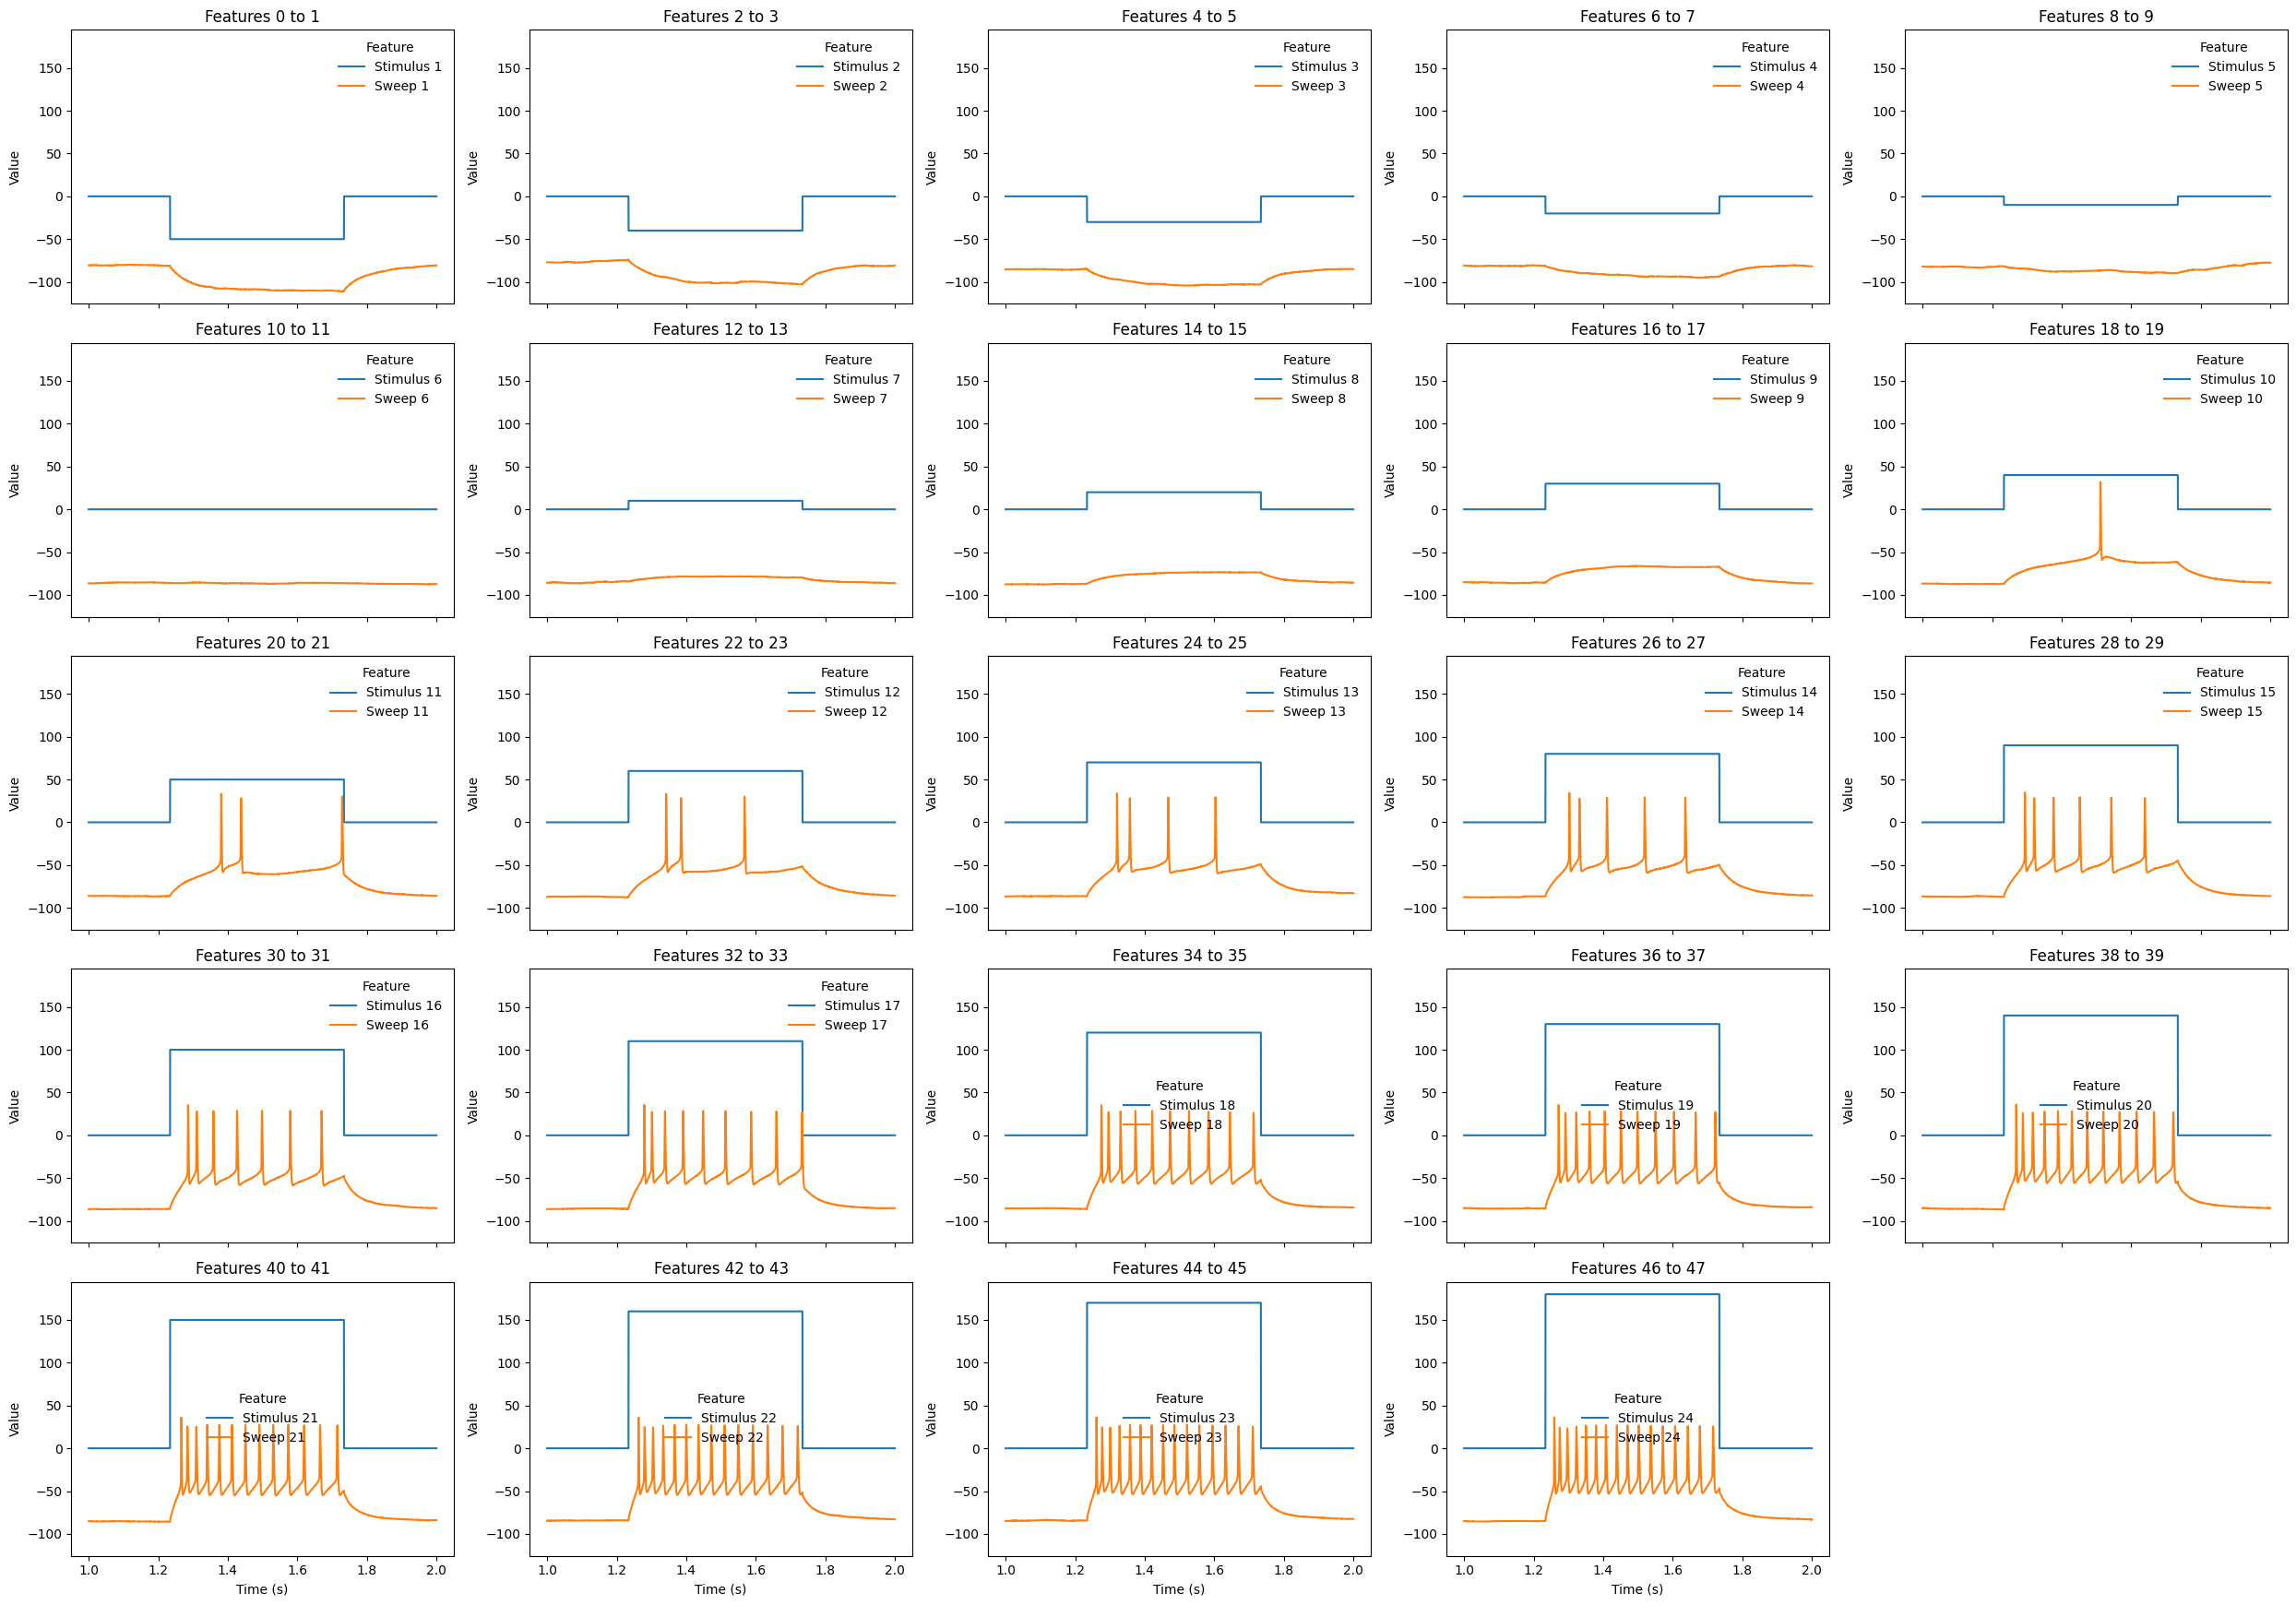

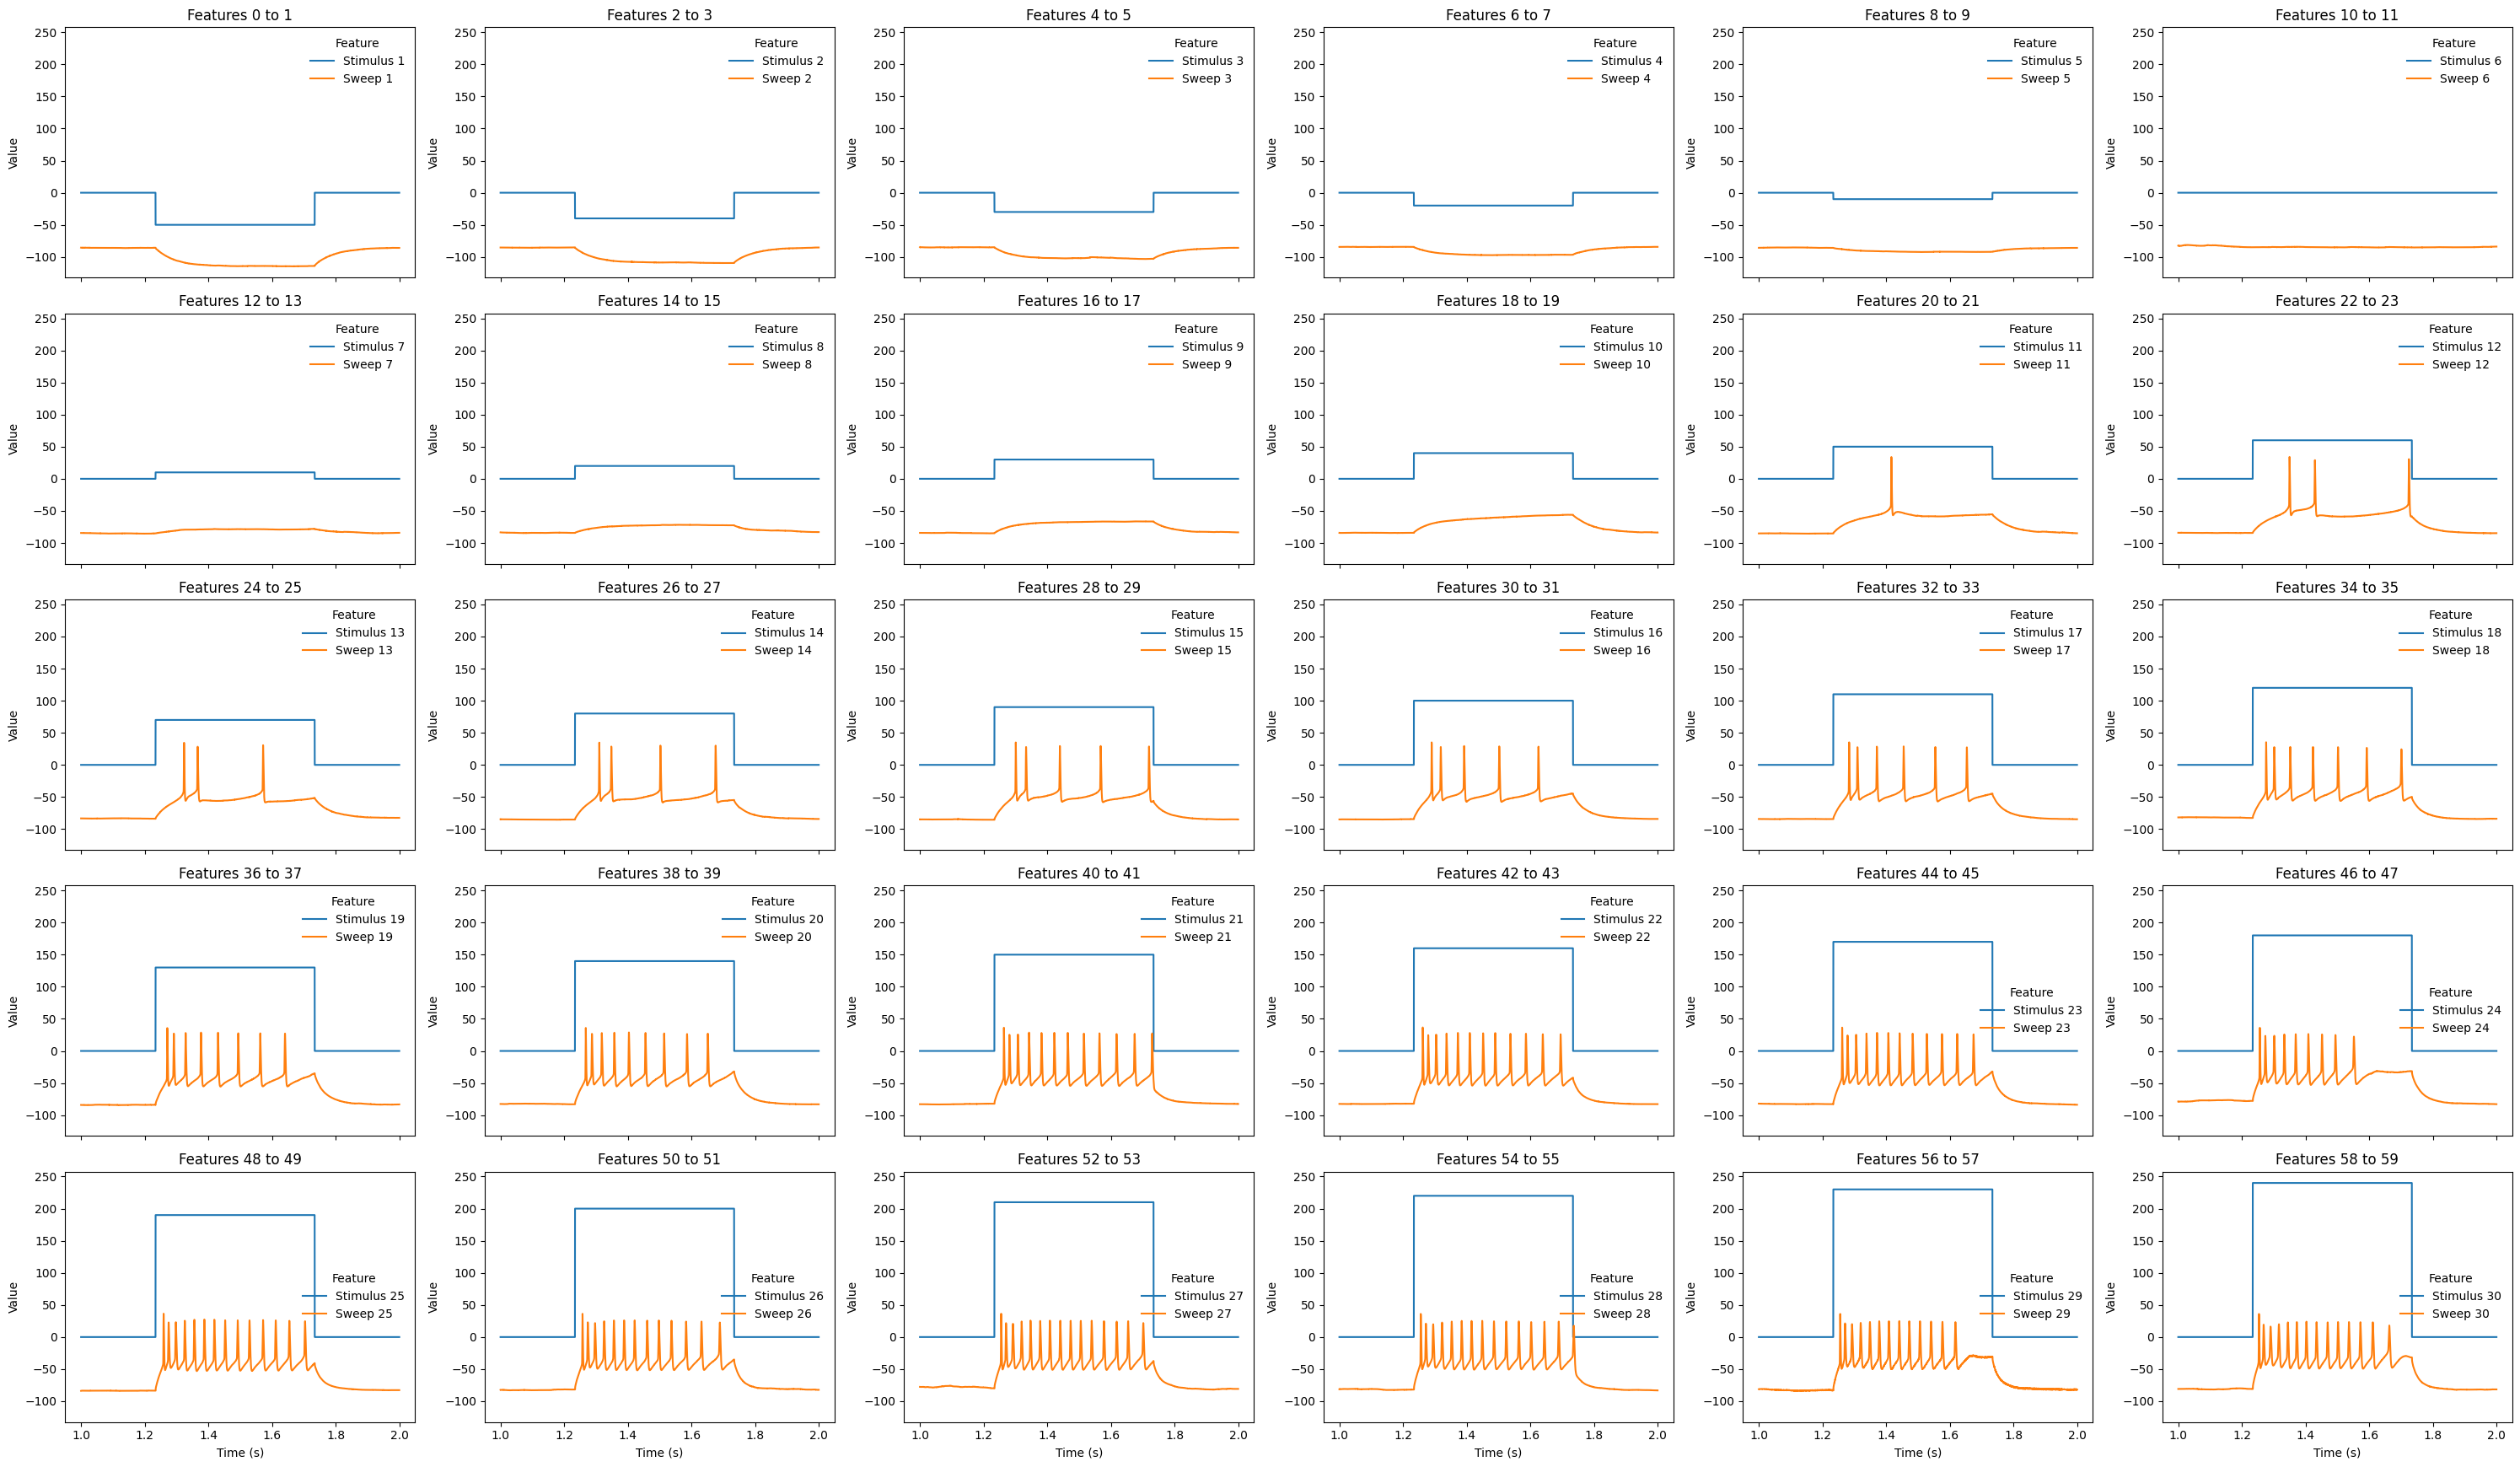

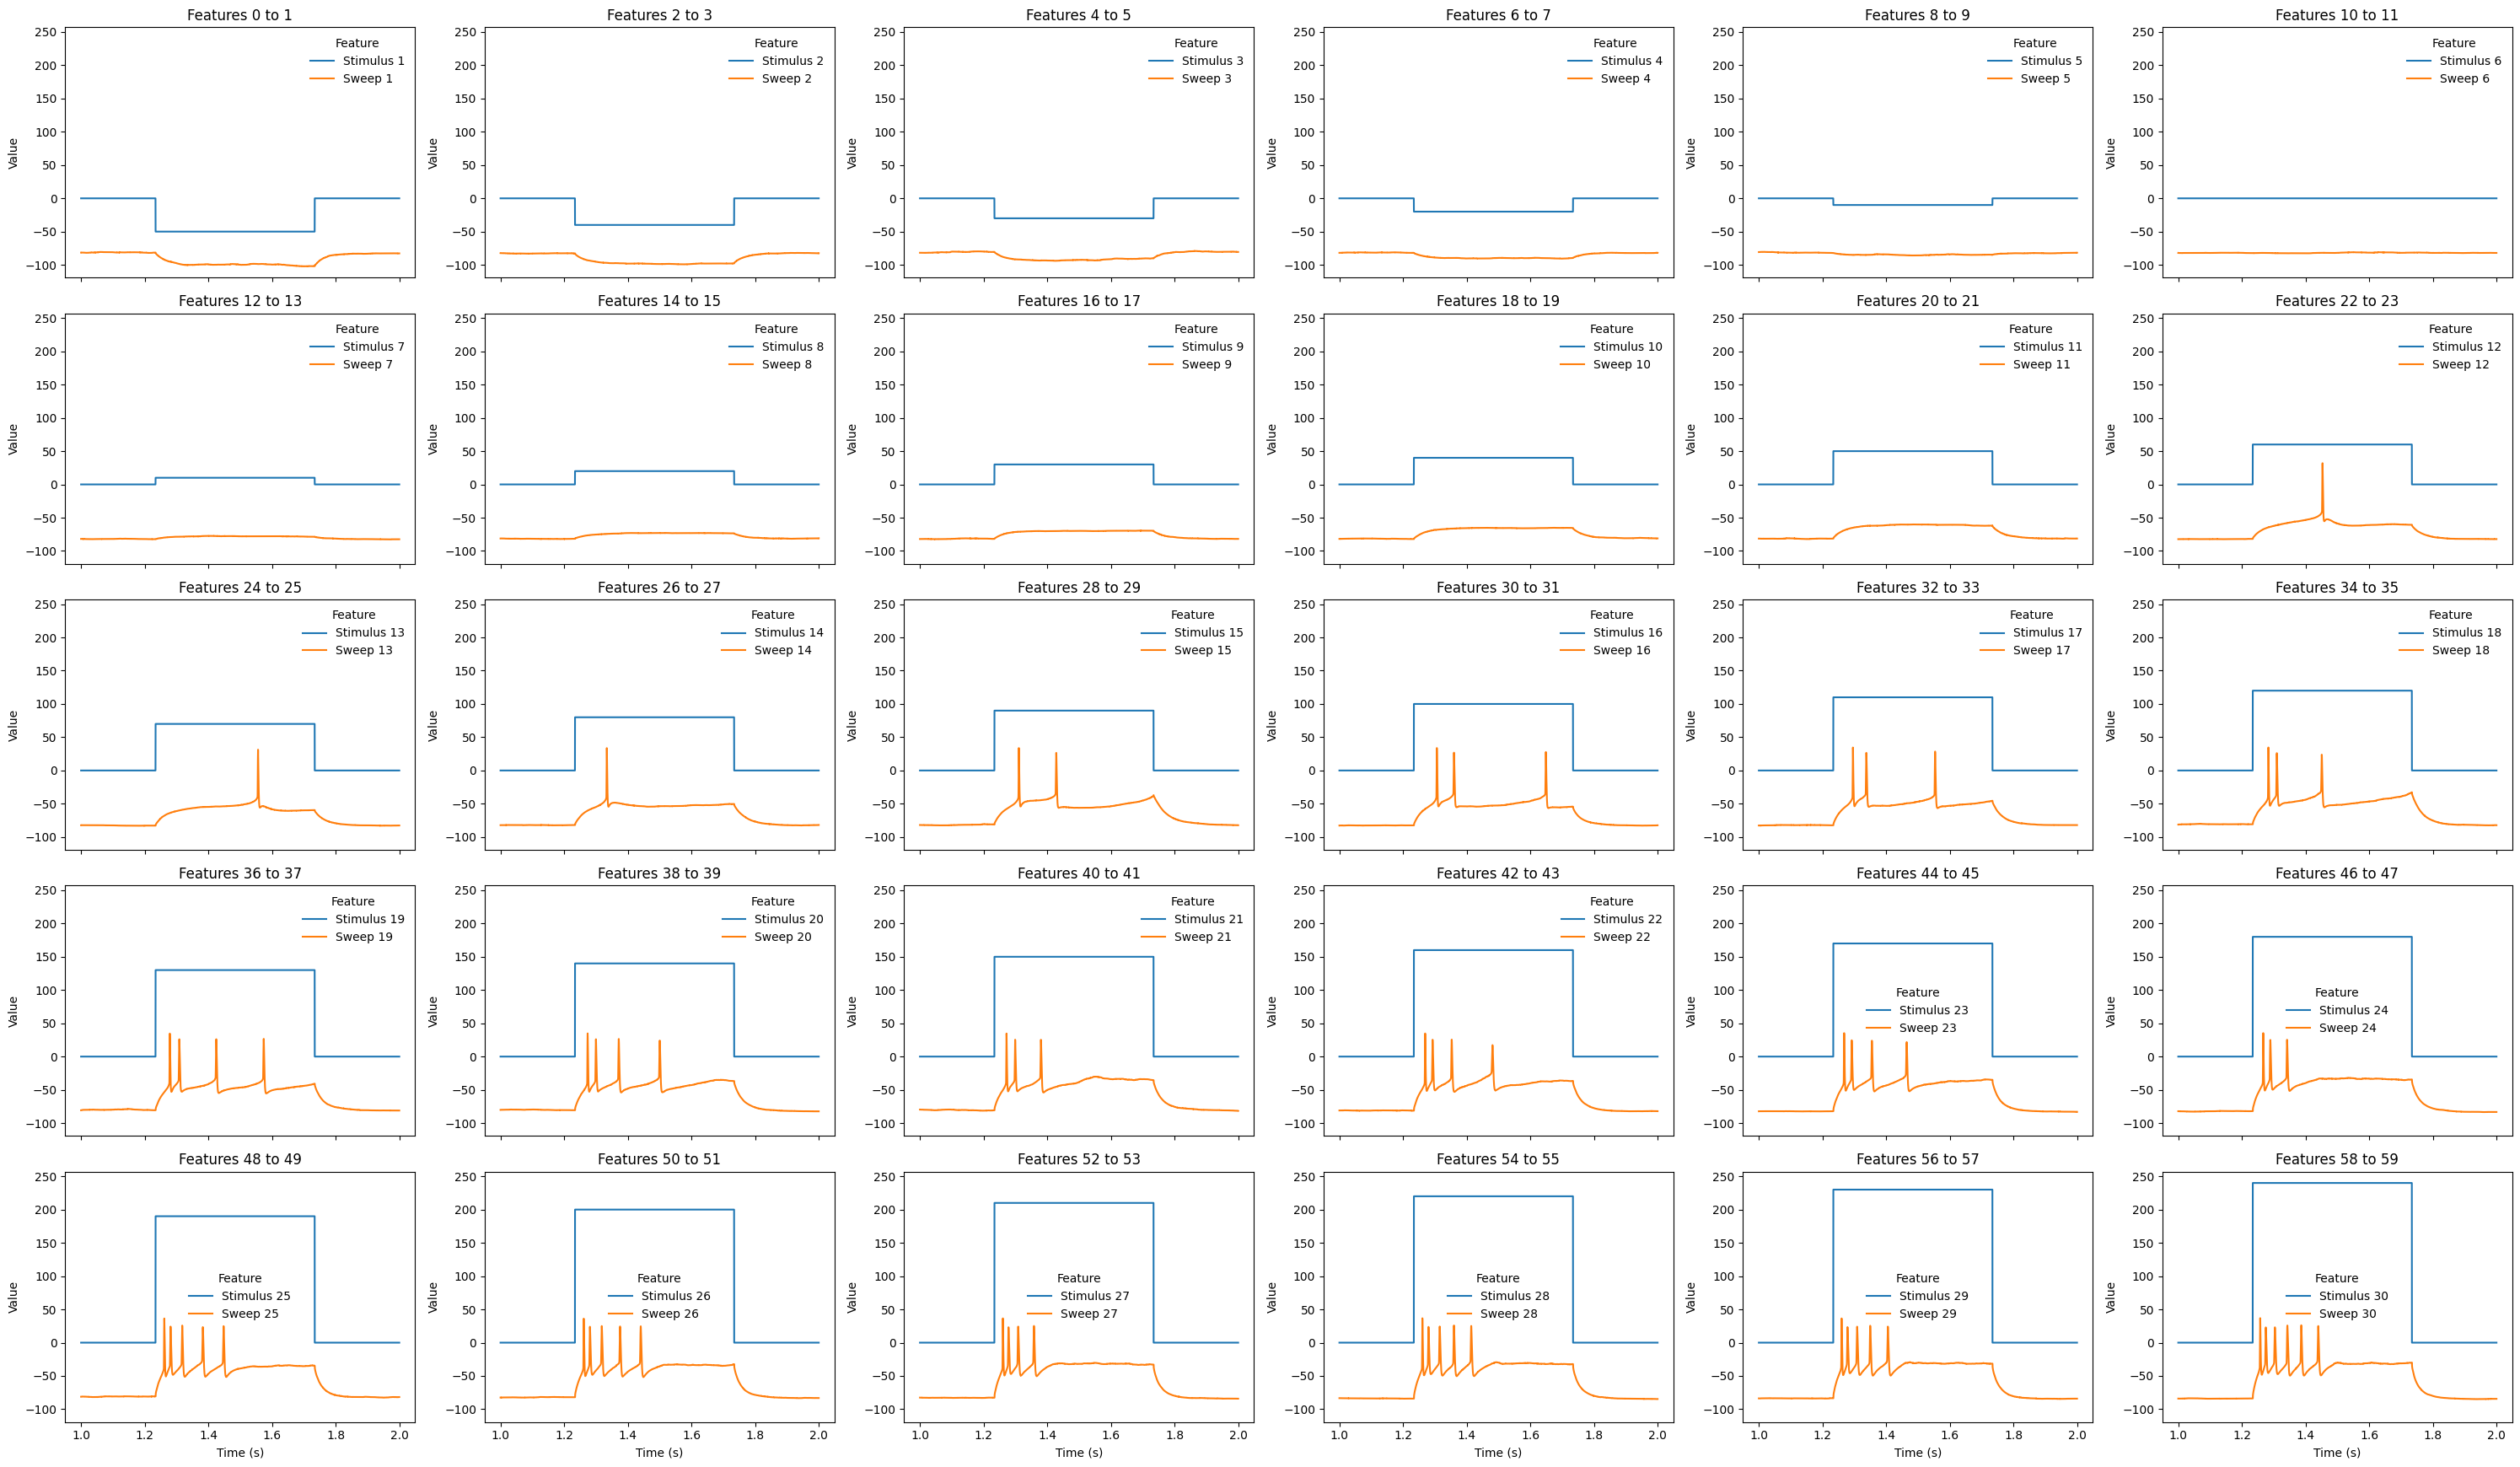

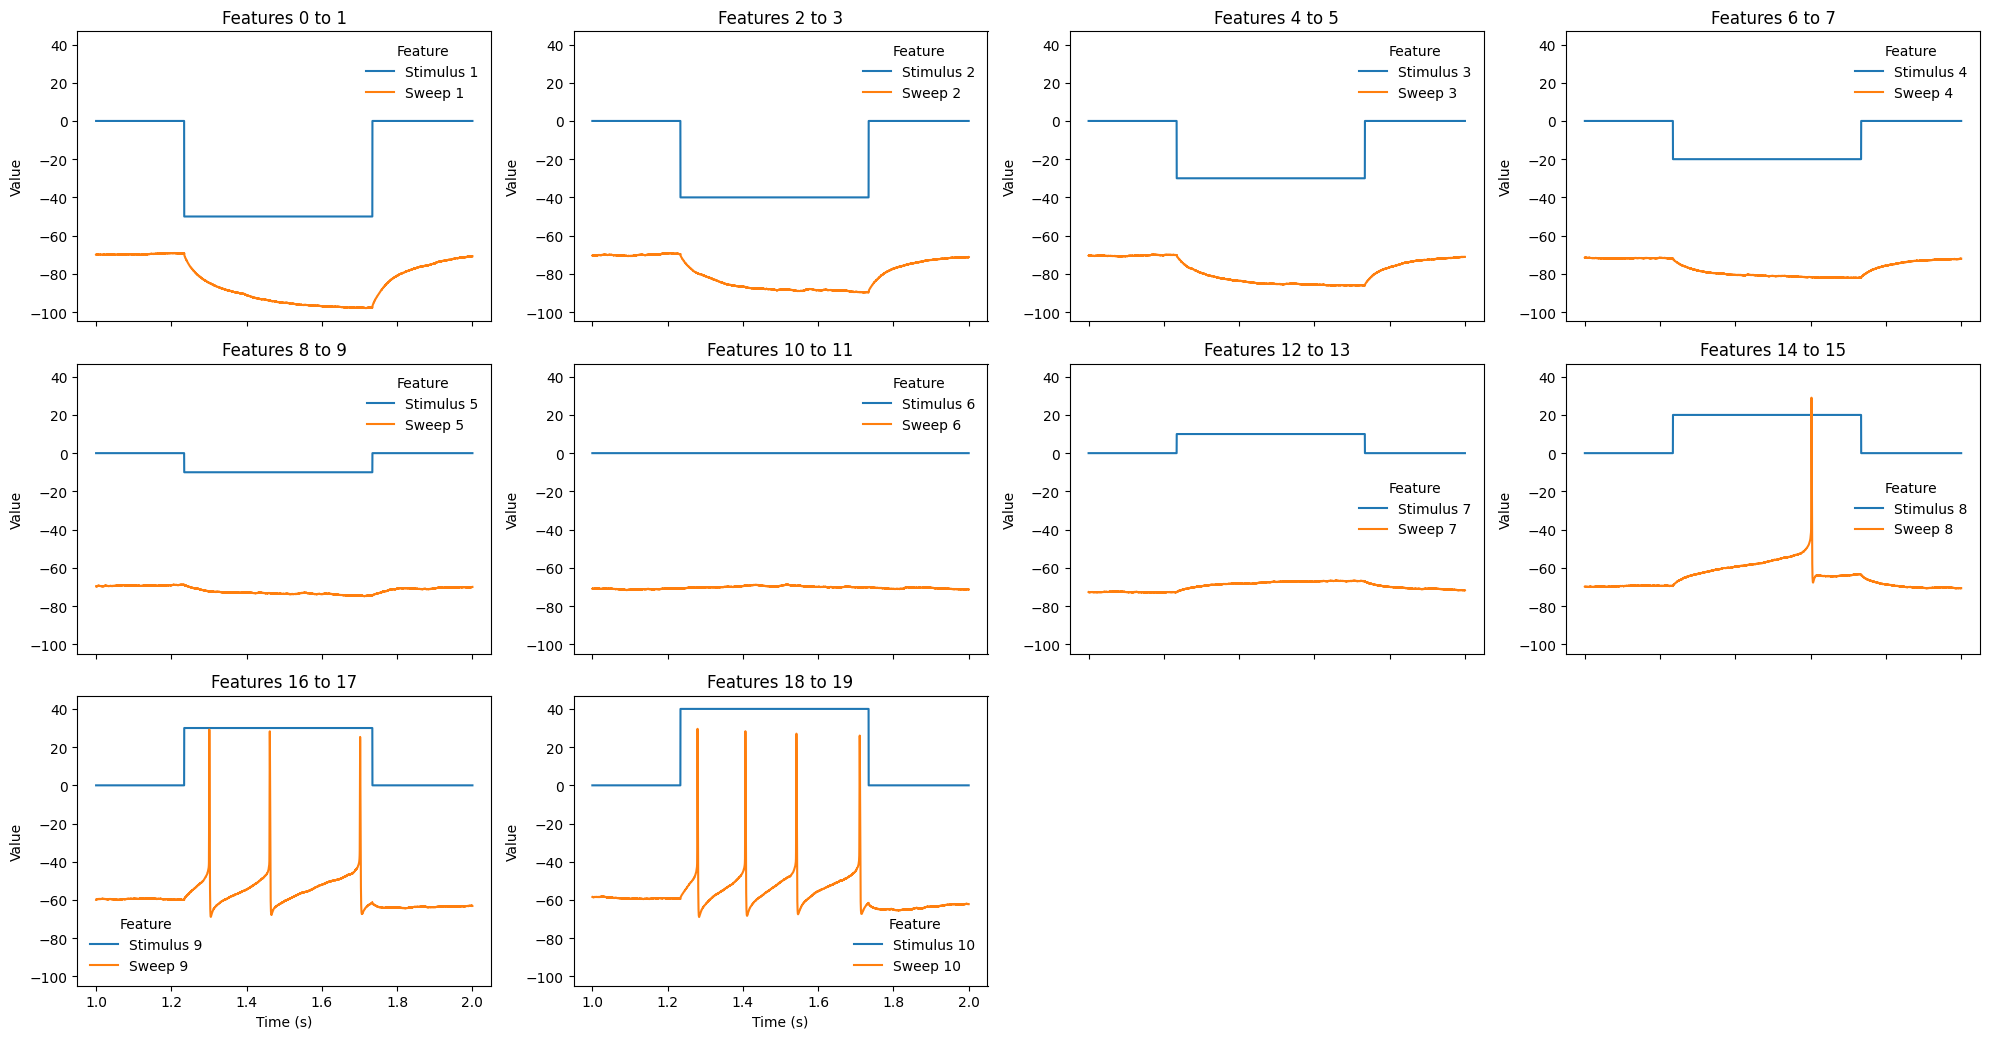

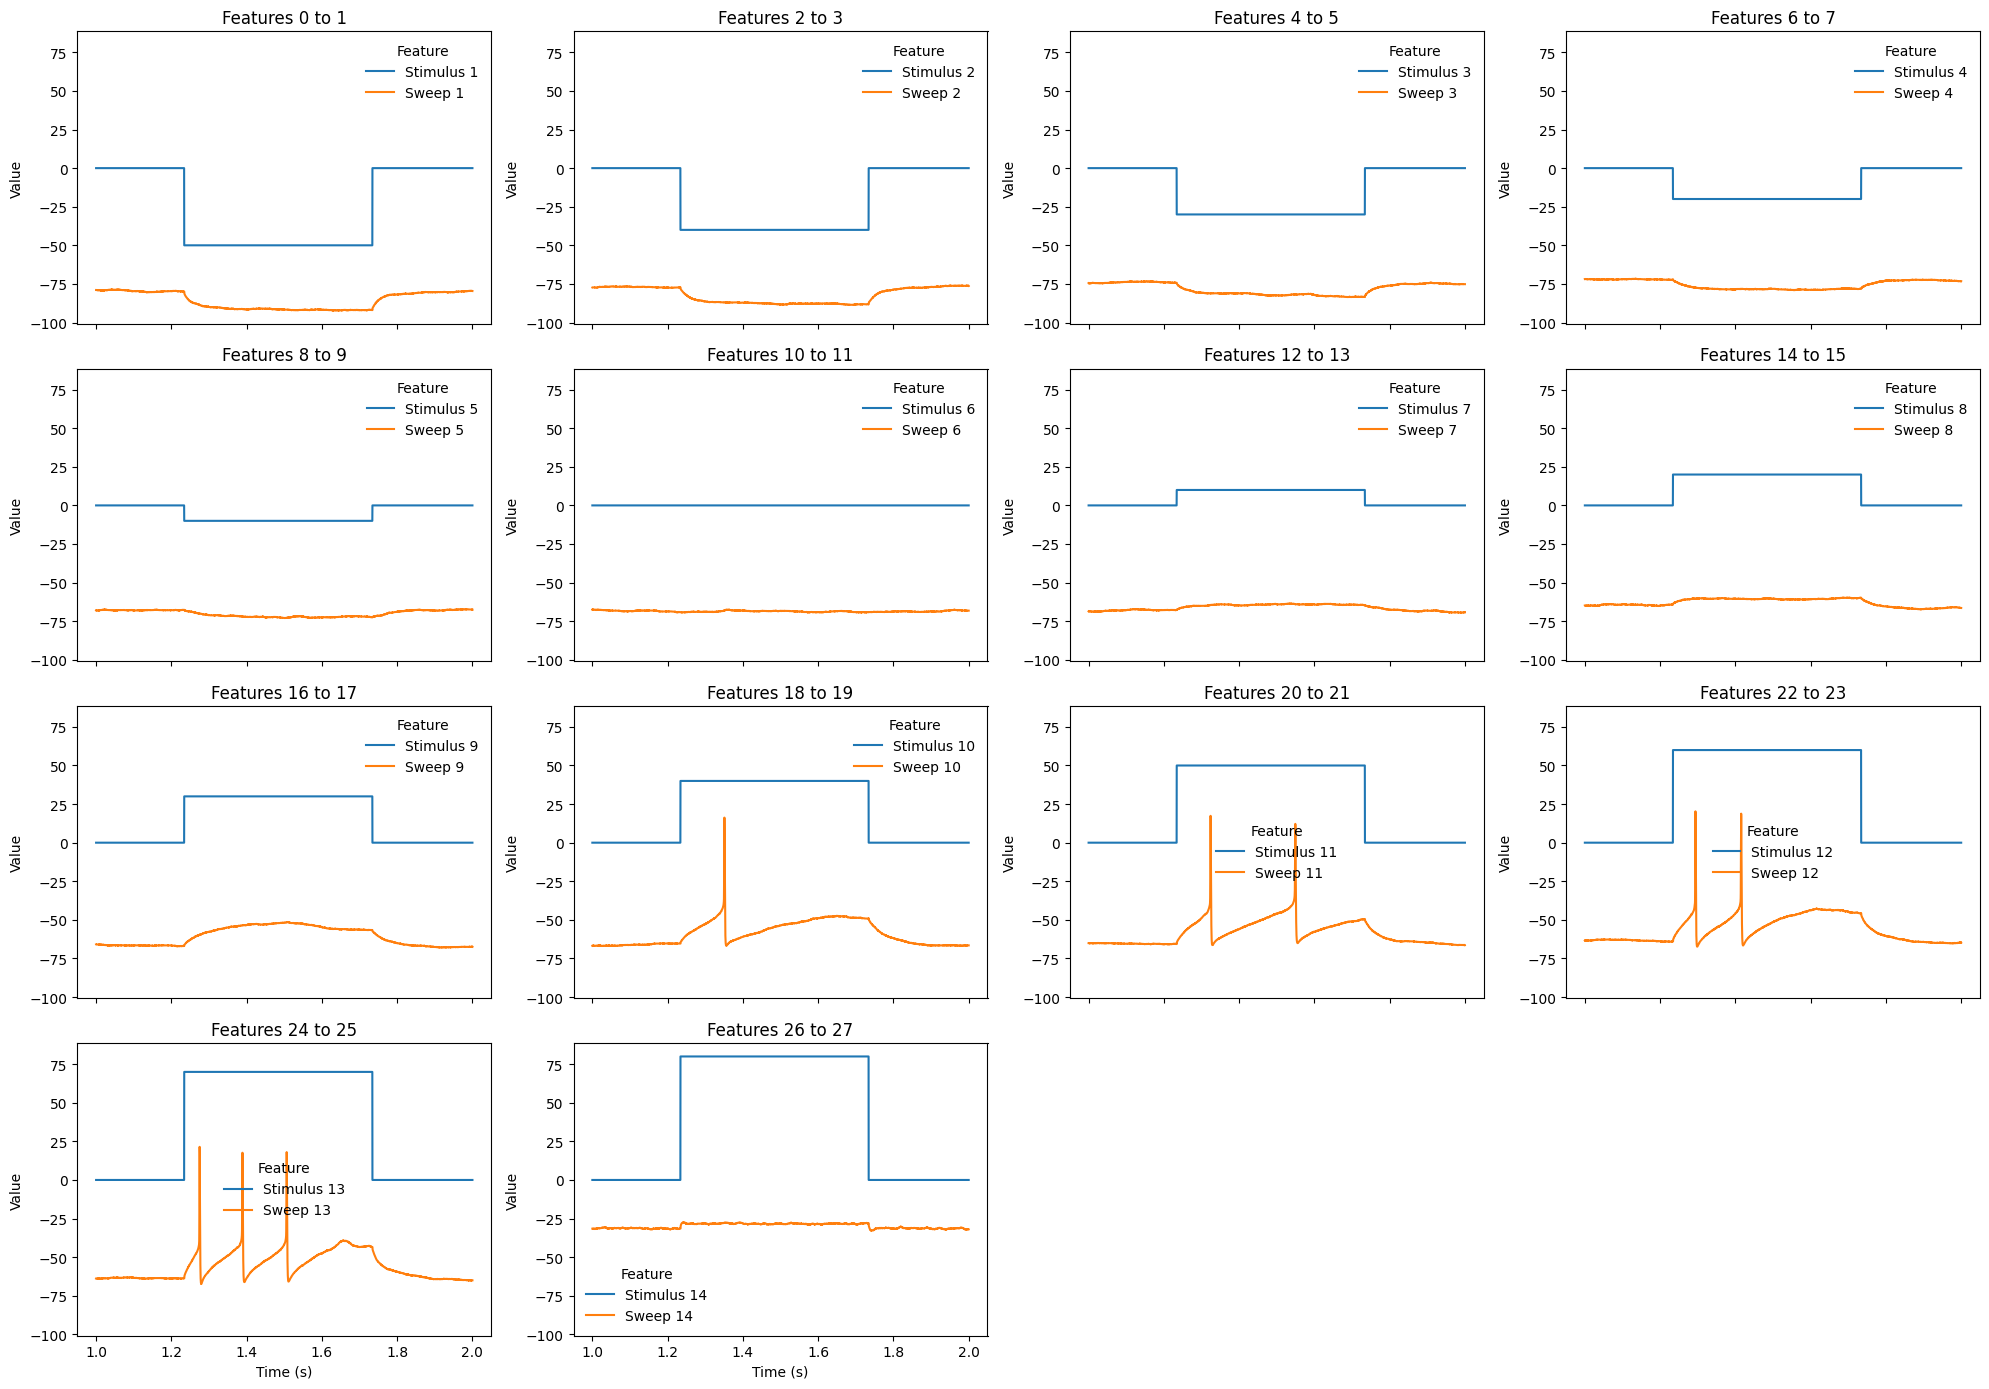

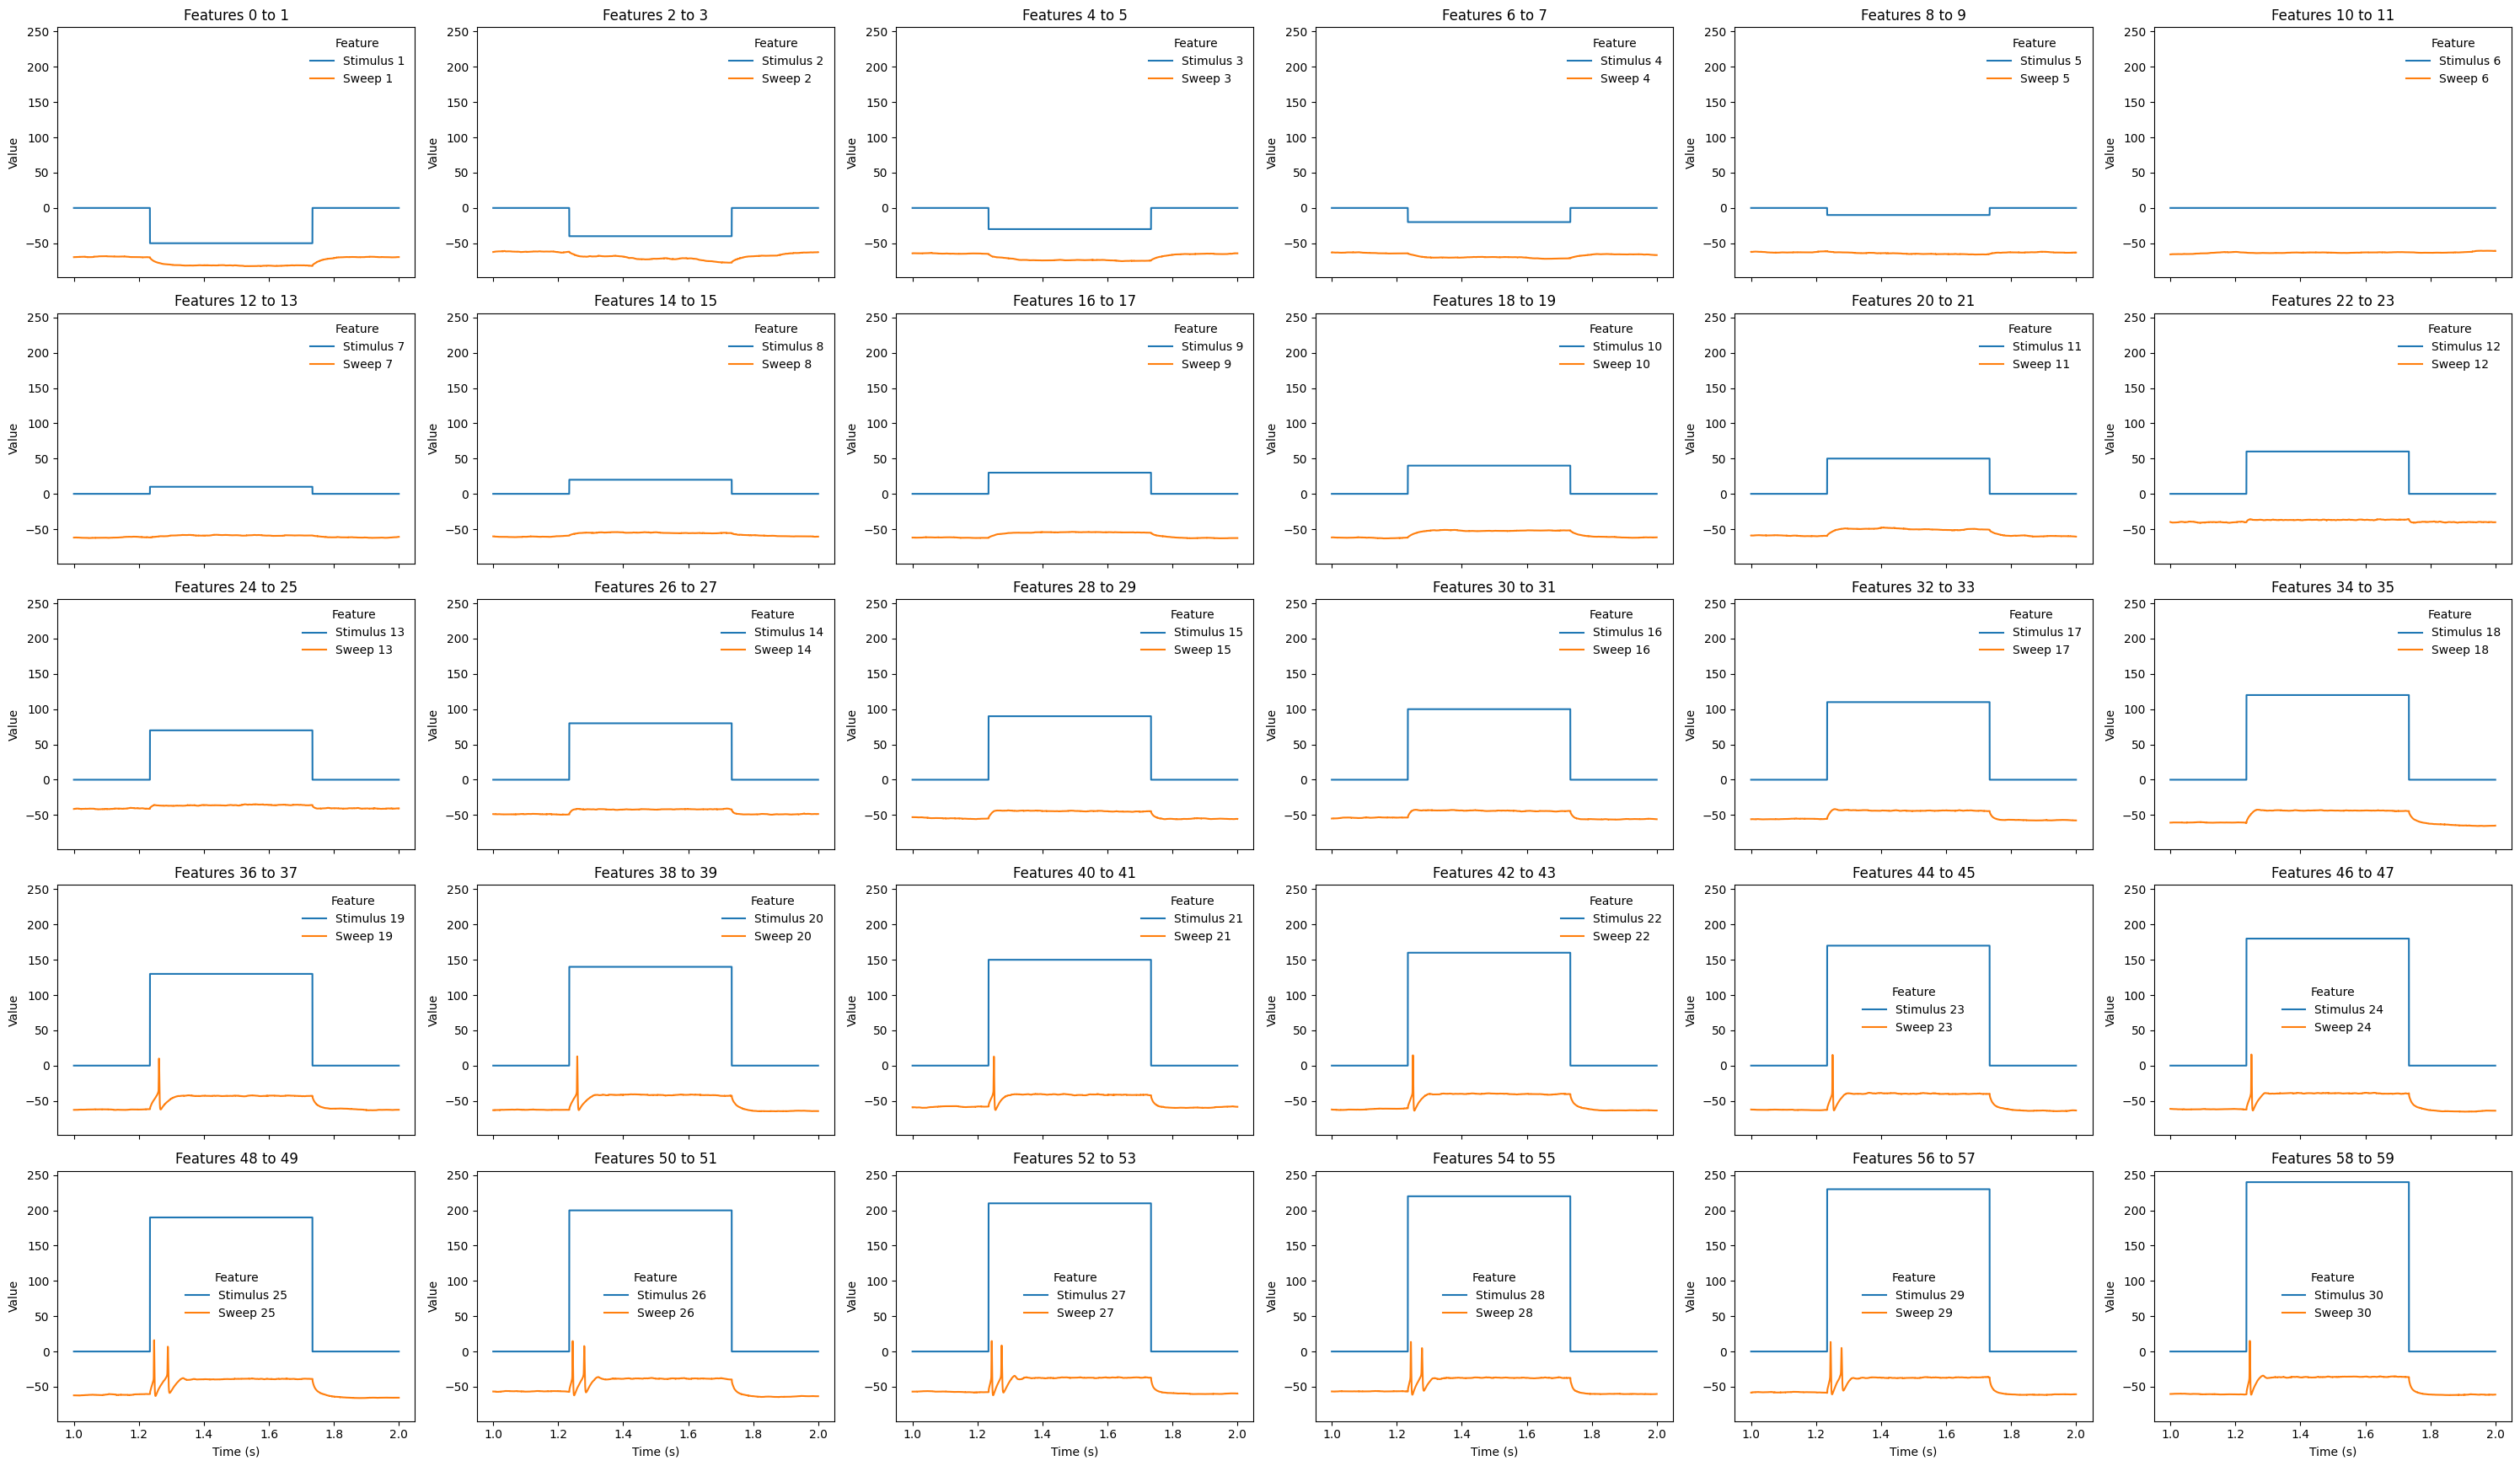

In [4]:
# save plots for restricted time

interval = nap.IntervalSet(start=1.0, end=2.0, time_units="s")
for fp in data_filepaths:
    dm = DataManager(fp)
    dm.data = dm.data.restrict(interval)
    fig, _ = dm.plot()
    name = Path(fp).stem
    fig.savefig(f"../figures/{name}_trunc.png")
    npz_filepath = f"../data/npz/{name}_trunc.npz"
    dm.write_npz(npz_filepath)

INFO:icxcca.data:Loading data from ../data/2022_04_14_0002.csv
INFO:icxcca.data:Loaded 30 features from ../data/2022_04_14_0002.csv


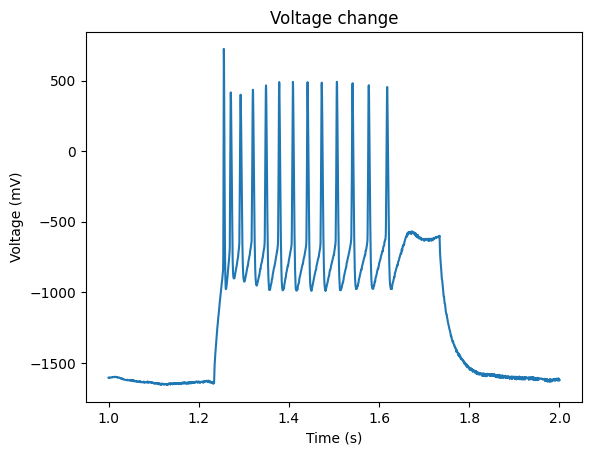

In [11]:
data_filename = "../data/2022_04_14_0002.csv"
data = get_data(data_filename)
interval = nap.IntervalSet(start=1.0, end=2.0)
data = data.restrict(interval)

trace = data[:, 28].decimate(down=4)

plt.figure()
plt.plot(trace, marker="")
plt.xlabel("Time (s)")
plt.title("Voltage change")
plt.ylabel("Voltage (mV)")
plt.show()

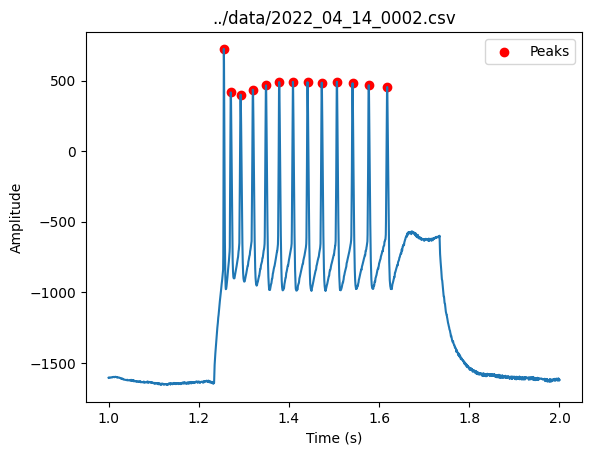

In [12]:
from scipy.signal import find_peaks
import numpy as np
import matplotlib.pyplot as plt

def get_spike_info(trace, threshold = None):
    time = trace.t
    signal = trace.d
    signal_min = np.min(signal)
    signal_max = np.max(signal)
    n_samples = len(signal)
    if threshold is None:
        threshold = signal_max - 0.2 * (signal_max - signal_min)
    indices, properties = find_peaks(signal, height=threshold, distance=n_samples//100)
    spike_times = time[indices]
    spike_amplitudes = signal[indices]
    return spike_times, spike_amplitudes, properties



# calculate spike info and plot
def plot_spike_info(trace, title):
    peak_times, peak_amplitudes, peak_properties = get_spike_info(trace)
    plt.figure()
    plt.plot(trace, marker="")
    plt.scatter(peak_times, peak_amplitudes, color="red", label="Peaks")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.show()


plot_spike_info(trace, data_filename)

Number of features: 24


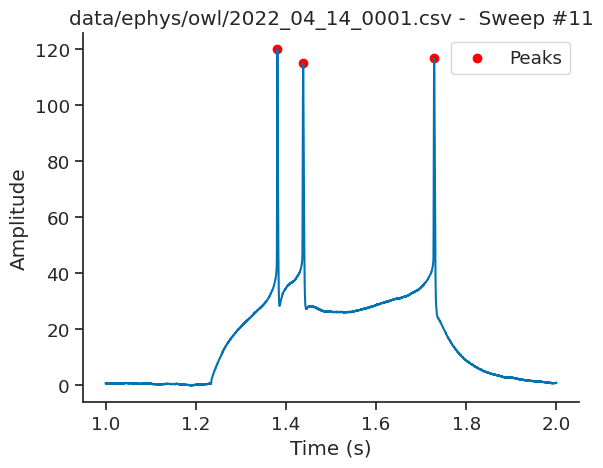

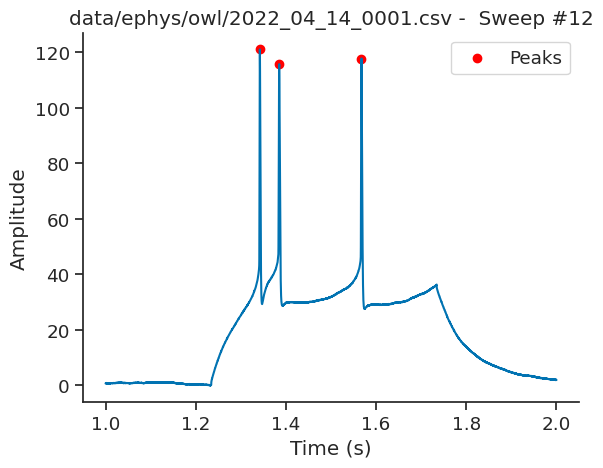

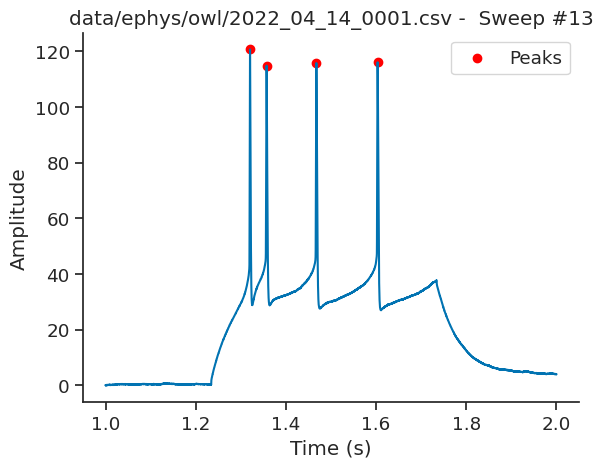

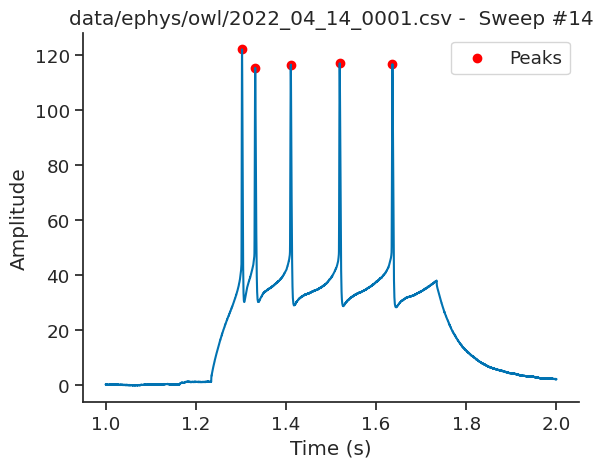

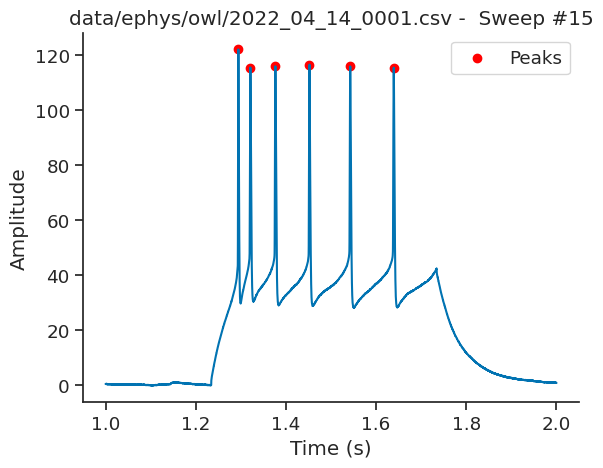

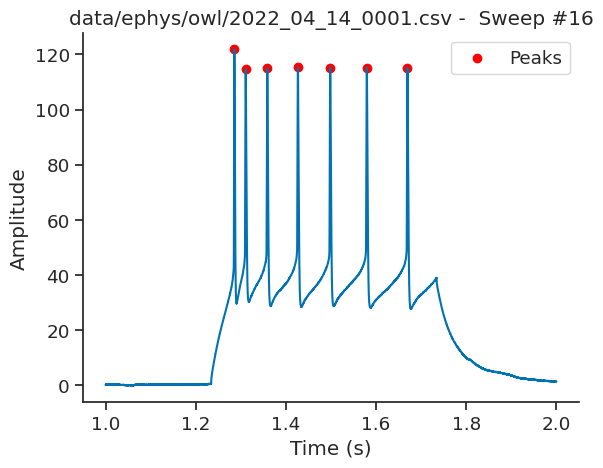

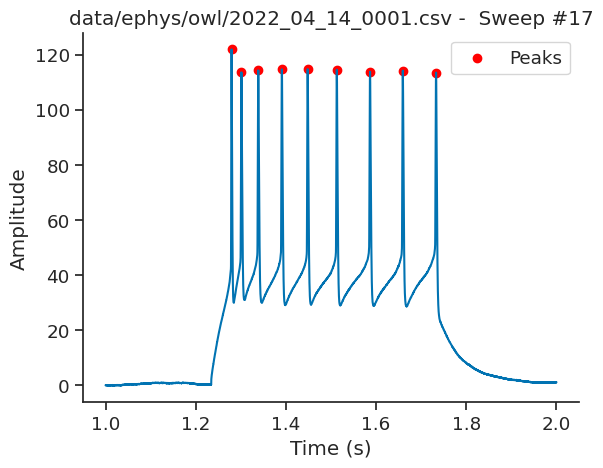

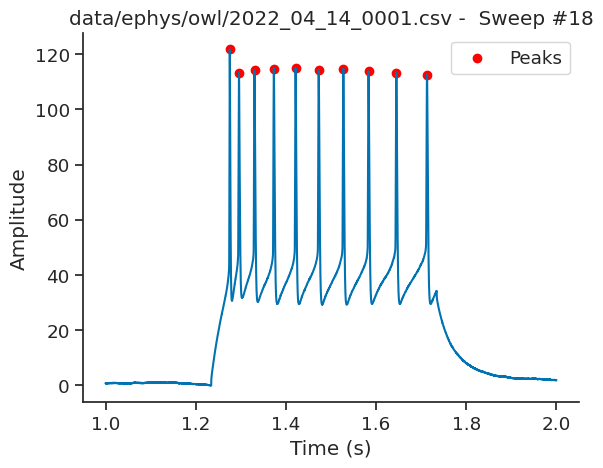

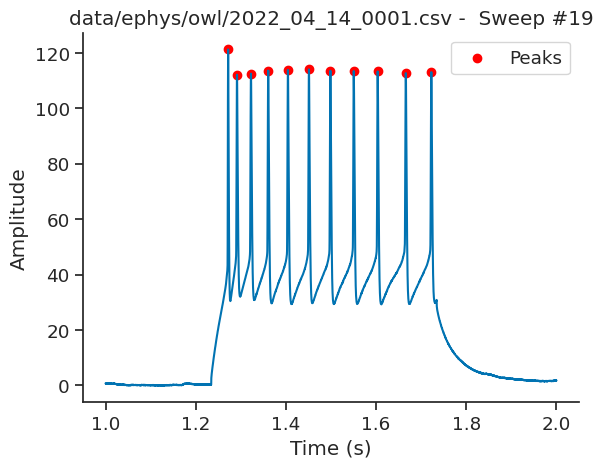

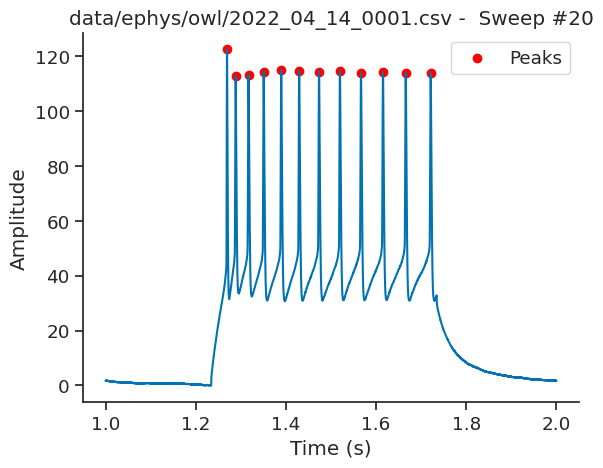

In [ ]:
# do this for all stimuli
data_filename = "data/ephys/owl/2022_04_14_0001.csv"
data = get_data(data_filename)
interval = nap.IntervalSet(start=1.0, end=2.0)
data = data.restrict(interval)
process = lambda x: (x - np.min(x)) / 20
trace = lambda n: process(data[:, n])

for i in range(10, 20):
    title = f"{data_filename} - {data.columns[i]}"
    plot_spike_info(trace(i), title)